# ***Evaluating Bias in Readmission Prediction Models: Demographic Disparities in Diabetic Patient Outcomes***

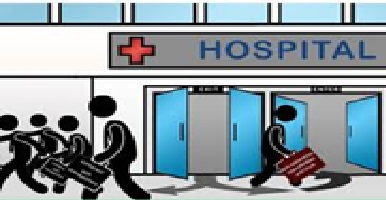

# Environment setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Import the required libraries -
# numpy, pandas for data manipulation,
# matplotlib, seaborn for visualization,
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Remove the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Set the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)
# Set the precision of floating numbers to 5 decimal points
pd.set_option("display.float_format", lambda x: "%.5f" % x)

# Library for scaling
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler

# Library to split data
from sklearn.model_selection import train_test_split

# To build model for prediction
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.utils import resample
from scipy.stats import ttest_rel
from scipy.stats import chi2_contingency

# To get diferent metric scores
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
)

# To ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

# Load Data and perform Basic checks

In [ ]:
# Read the data from diabetic data csv file
DiabData_df = pd.read_csv(
    "/content/drive/MyDrive/Capstone project QM640/diabetic_data.csv",
    na_values=["?"],   # only treat '?' as missing
    keep_default_na=False
)

In [ ]:
# Create a copy of original data set as back-up
DiabData_backupcopy = DiabData_df.copy()

In [ ]:
# Use the shape function to get the number of rows and columns in the data set
DiabData_df.shape

(101766, 50)

In [ ]:
# Find the datatypes of various columns in this data set using the 'info()' function
DiabData_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      99493 non-null   object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    3197 non-null    object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                61510 non-null   object
 11  medical_specialty         51817 non-null   object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [ ]:
# View the first 5 rows from the data set
DiabData_df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,NaN,NaN,1,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,59,0,18,0,0,0,276,250.01,255,9,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,11,5,13,2,0,1,648,250,V27,6,None,None,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN,44,1,16,0,0,0,8,250.43,403,7,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,51,0,8,0,0,0,197,157,250,5,None,None,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [ ]:
# View the last 5 rows from the data set
DiabData_df.tail()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
101761,443847548,100162476,AfricanAmerican,Male,[70-80),NaN,1,3,7,3,MC,NaN,51,0,16,0,0,0,250.13,291,458,9,None,>8,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Down,No,No,No,No,No,Ch,Yes,>30
101762,443847782,74694222,AfricanAmerican,Female,[80-90),NaN,1,4,5,5,MC,NaN,33,3,18,0,0,1,560,276,787,9,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,Yes,NO
101763,443854148,41088789,Caucasian,Male,[70-80),NaN,1,1,7,1,MC,NaN,53,0,9,1,0,0,38,590,296,13,None,None,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Down,No,No,No,No,No,Ch,Yes,NO
101764,443857166,31693671,Caucasian,Female,[80-90),NaN,2,3,7,10,MC,Surgery-General,45,2,21,0,0,1,996,285,998,9,None,None,No,No,No,No,No,No,Steady,No,No,Steady,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
101765,443867222,175429310,Caucasian,Male,[70-80),NaN,1,1,7,6,NaN,NaN,13,3,3,0,0,0,530,530,787,9,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO


In [ ]:
# Find missing values in data - by using the isnull() function and summing the count of null values
DiabData_df.isnull().sum()

,0
encounter_id,0
patient_nbr,0
race,2273
gender,0
age,0
weight,98569
admission_type_id,0
discharge_disposition_id,0
admission_source_id,0
time_in_hospital,0


In [ ]:
# Find duplicate values in data - by using the duplicated () function and sum the count of null values
DiabData_df.duplicated().sum()

np.int64(0)

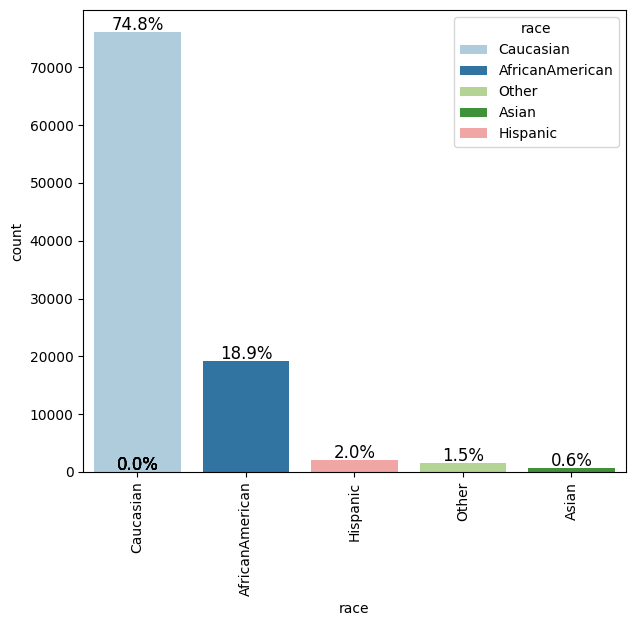

,count
race,
Caucasian,76099
AfricanAmerican,19210
Hispanic,2037
Other,1506
Asian,641


In [ ]:
# "Race" distribution in the original data
labeled_barplot(DiabData_backupcopy, "race", perc=True)
DiabData_backupcopy['race'].value_counts()

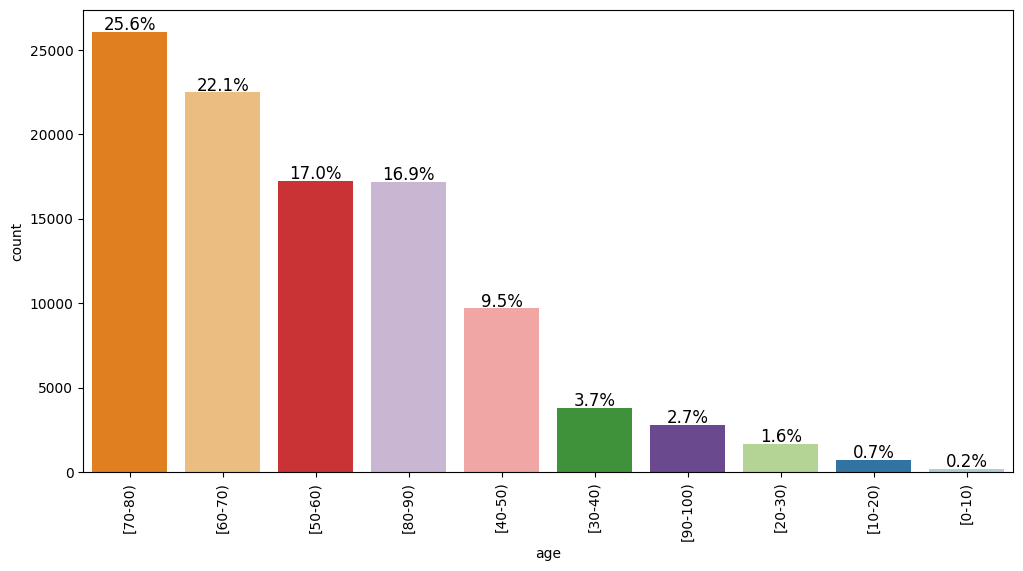

,count
age,
[70-80),26068
[60-70),22483
[50-60),17256
[80-90),17197
[40-50),9685
[30-40),3775
[90-100),2793
[20-30),1657
[10-20),691


In [ ]:
# "Race" distribution in the original data
labeled_barplot(DiabData_backupcopy, "age", perc=True)
DiabData_backupcopy['age'].value_counts()

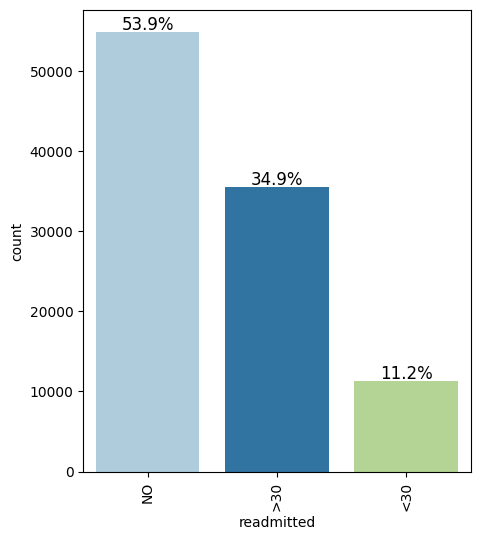

,count
readmitted,
NO,54864
>30,35545
<30,11357


In [ ]:
# "Readmitted" distribution in the original data
labeled_barplot(DiabData_backupcopy, "readmitted", perc=True)
DiabData_backupcopy['readmitted'].value_counts()

# Pre-process data

In [ ]:
# Replace '?' with NaN

DiabData_df = DiabData_df.replace('?', np.nan)

In [ ]:
# Drop coumns not relevant

# -------------------------------
# Columns to DROP
# -------------------------------

# Identifier columns (not useful for modeling)
id_cols = [
    'encounter_id',
    'patient_nbr'
]

# High-missing / low-value columns
high_missing_cols = [
    'weight',
    'payer_code',
    'medical_specialty'
]

# Diagnosis codes (complex, high cardinality)
diag_cols = [
    'diag_1',
    'diag_2',
    'diag_3'
]

# Medication columns (24+ columns)
medication_cols = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
    'glimepiride', 'acetohexamide', 'glipizide', 'glyburide',
    'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
    'miglitol', 'troglitazone', 'tolazamide', 'examide',
    'citoglipton', 'glyburide-metformin', 'glipizide-metformin',
    'glimepiride-pioglitazone', 'metformin-rosiglitazone',
    'metformin-pioglitazone'
]

# Combine all columns to drop
cols_to_drop = id_cols + high_missing_cols + diag_cols + medication_cols

# Drop columns safely (ignore if any column not present)
DiabData_df = DiabData_df.drop(columns=cols_to_drop, errors='ignore')

# -------------------------------
# Columns to KEEP explicitly (sanity check)
# -------------------------------

print("Remaining columns:")
print(DiabData_df.columns.tolist())

print("\nShape after dropping columns:")
print(DiabData_df.shape)

Remaining columns:
['race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'insulin', 'change', 'diabetesMed', 'readmitted']

Shape after dropping columns:
(101766, 20)


In [ ]:
# Create age group mapping
def map_age_group(age):
    if age in ['[60-70)', '[70-80)']:
        return 'Senior'
    else:
        return 'Upto60'

DiabData_df['age_group'] = DiabData_df['age'].apply(map_age_group)

# Check distribution
print(DiabData_df['age_group'].value_counts())

age_group
Upto60    53215
Senior    48551
Name: count, dtype: int64


In [ ]:
# encode caegorical variables

DiabData_df['readmitted_binary'] = DiabData_df['readmitted'].apply(
    lambda x: 0 if x == 'NO' else 1
)

# Check distribution
print(DiabData_df['readmitted_binary'].value_counts())

readmitted_binary
0    54864
1    46902
Name: count, dtype: int64


In [ ]:
print(DiabData_df[['age_group', 'readmitted_binary']].head())

print("\nAge group distribution:")
print(DiabData_df['age_group'].value_counts(normalize=True))

print("\nReadmission distribution:")
print(DiabData_df['readmitted_binary'].value_counts(normalize=True))

  age_group  readmitted_binary
0    Upto60                  0
1    Upto60                  1
2    Upto60                  0
3    Upto60                  0
4    Upto60                  0

Age group distribution:
age_group
Upto60   0.52292
Senior   0.47708
Name: proportion, dtype: float64

Readmission distribution:
readmitted_binary
0   0.53912
1   0.46088
Name: proportion, dtype: float64


In [ ]:
# drop original age column
DiabData_df = DiabData_df.drop(columns=['age'])
# drop original column
DiabData_df = DiabData_df.drop(columns=['readmitted'])

In [ ]:
# Check unique values for race
print(DiabData_df['race'].unique())

['Caucasian' 'AfricanAmerican' nan 'Other' 'Asian' 'Hispanic']


In [ ]:
print(DiabData_df['race'].value_counts())

race
Caucasian          76099
AfricanAmerican    19210
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64


In [ ]:
# check if ach race group has enough samples for doing the Reasearch questions
DiabData_df.groupby('race')['readmitted_binary'].sum()

,readmitted_binary
race,
AfricanAmerican,8789
Asian,226
Caucasian,35716
Hispanic,854
Other,591


“Due to limited representation of certain racial categories, smaller groups (Hispanic, Asian, and Other) were combined into a single ‘Other Minority’ category. This approach ensures sufficient sample size for statistical testing while preserving representation of minority populations.”

In [ ]:
def group_race(x):
    if x == 'Caucasian':
        return 'Caucasian'
    elif x == 'AfricanAmerican':
        return 'AfricanAmerican'
    else:
        return 'Other_Minority'

DiabData_df['race_group'] = DiabData_df['race'].apply(group_race)

# Drop original column
DiabData_df = DiabData_df.drop(columns=['race'])

print(DiabData_df['race_group'].value_counts())

race_group
Caucasian          76099
AfricanAmerican    19210
Other_Minority      6457
Name: count, dtype: int64


# Exploratory Data Analysis

In [ ]:
# Function to create labeled barplots

def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    plt.xticks(rotation=90, fontsize=10)
    ax = sns.countplot(
        data=data,
        x=feature,
        hue=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n],
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

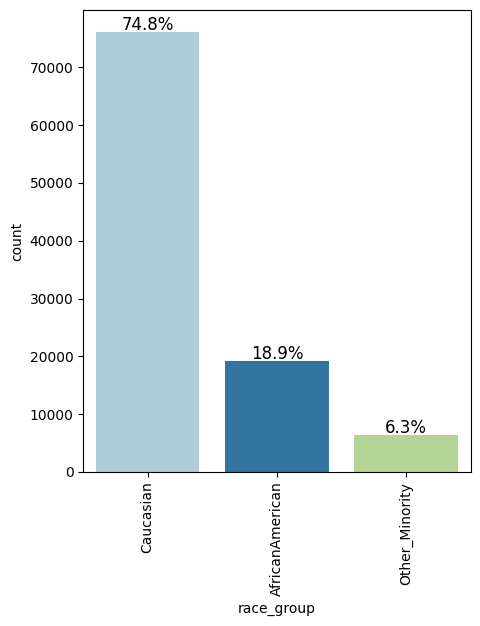

,count
race_group,
Caucasian,76099
AfricanAmerican,19210
Other_Minority,6457


In [ ]:
# "Race" distribution
labeled_barplot(DiabData_df, "race_group", perc=True)
DiabData_df['race_group'].value_counts()

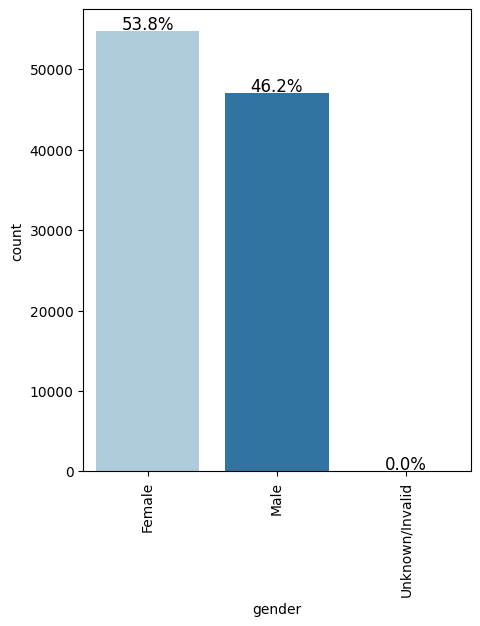

,count
gender,
Female,54708
Male,47055
Unknown/Invalid,3


In [ ]:
# "Gender" distribution
labeled_barplot(DiabData_df, "gender", perc=True)
DiabData_df['gender'].value_counts()

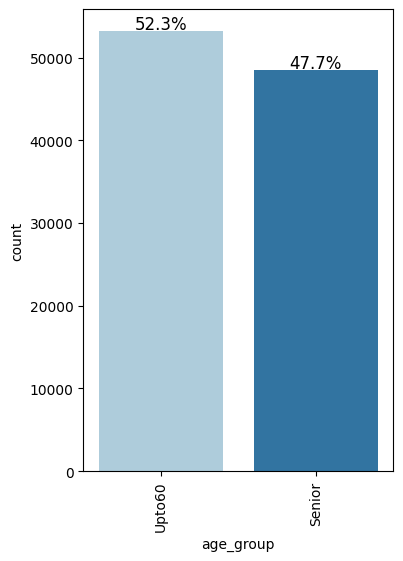

,count
age_group,
Upto60,53215
Senior,48551


In [ ]:
# "Age" distribution
labeled_barplot(DiabData_df, "age_group", perc=True)
DiabData_df['age_group'].value_counts()

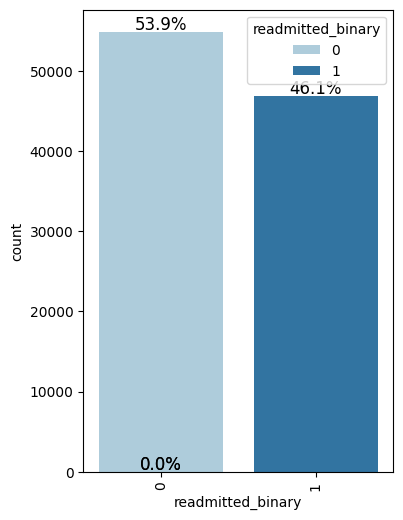

,count
readmitted_binary,
0,54864
1,46902


In [ ]:
# "Readmitted" distribution
labeled_barplot(DiabData_df, "readmitted_binary", perc=True)
DiabData_df['readmitted_binary'].value_counts()

In [ ]:
# Using the shape function to get the number of rows and columns in the data set
DiabData_df.shape

(101766, 20)

In [ ]:
# Finding the datatypes of various columns in this data set using the 'info()' function
DiabData_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 20 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   gender                    101766 non-null  object
 1   admission_type_id         101766 non-null  int64 
 2   discharge_disposition_id  101766 non-null  int64 
 3   admission_source_id       101766 non-null  int64 
 4   time_in_hospital          101766 non-null  int64 
 5   num_lab_procedures        101766 non-null  int64 
 6   num_procedures            101766 non-null  int64 
 7   num_medications           101766 non-null  int64 
 8   number_outpatient         101766 non-null  int64 
 9   number_emergency          101766 non-null  int64 
 10  number_inpatient          101766 non-null  int64 
 11  number_diagnoses          101766 non-null  int64 
 12  max_glu_serum             101766 non-null  object
 13  A1Cresult                 101766 non-null  object
 14  insu

In [ ]:
# Find missing values in data - by using the isnull() function and summing the count of null values
DiabData_df.isnull().sum()

,0
gender,0
admission_type_id,0
discharge_disposition_id,0
admission_source_id,0
time_in_hospital,0
num_lab_procedures,0
num_procedures,0
num_medications,0
number_outpatient,0
number_emergency,0


In [ ]:
# Find the statistical summary of numerical data using the describe() function
DiabData_df.describe().T

,count,mean,std,min,25%,50%,75%,max
admission_type_id,101766.00000,2.02401,1.44540,1.00000,1.00000,1.00000,3.00000,8.00000
discharge_disposition_id,101766.00000,3.71564,5.28017,1.00000,1.00000,1.00000,4.00000,28.00000
admission_source_id,101766.00000,5.75444,4.06408,1.00000,1.00000,7.00000,7.00000,25.00000
time_in_hospital,101766.00000,4.39599,2.98511,1.00000,2.00000,4.00000,6.00000,14.00000
num_lab_procedures,101766.00000,43.09564,19.67436,1.00000,31.00000,44.00000,57.00000,132.00000
num_procedures,101766.00000,1.33973,1.70581,0.00000,0.00000,1.00000,2.00000,6.00000
num_medications,101766.00000,16.02184,8.12757,1.00000,10.00000,15.00000,20.00000,81.00000
number_outpatient,101766.00000,0.36936,1.26727,0.00000,0.00000,0.00000,0.00000,42.00000
number_emergency,101766.00000,0.19784,0.93047,0.00000,0.00000,0.00000,0.00000,76.00000
number_inpatient,101766.00000,0.63557,1.26286,0.00000,0.00000,0.00000,1.00000,21.00000


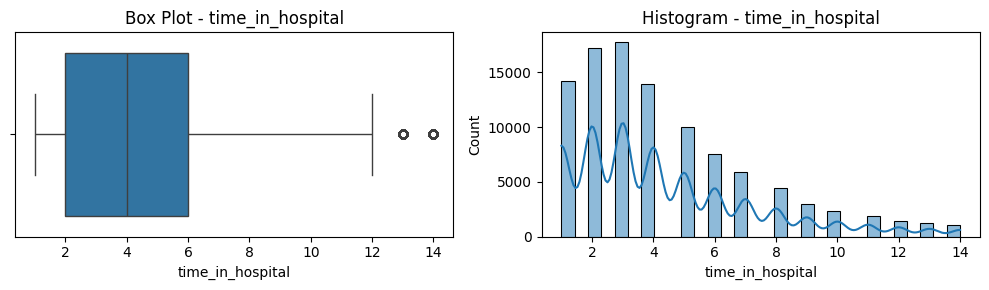

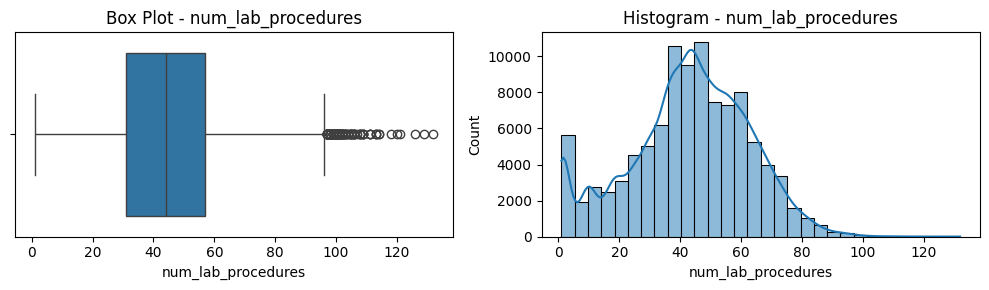

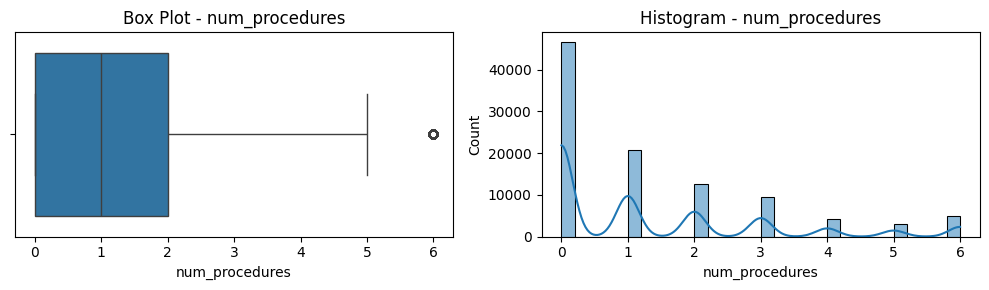

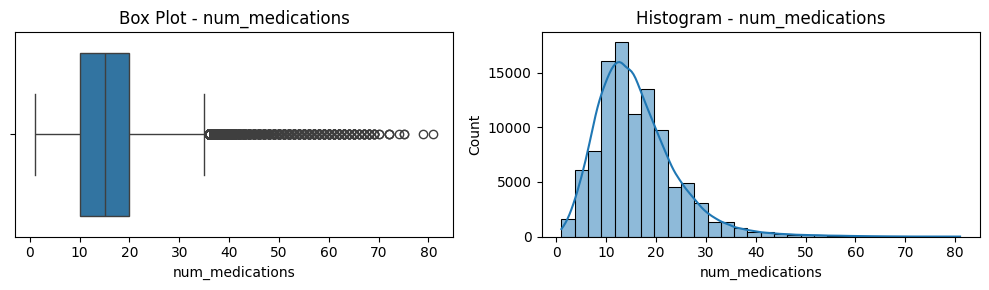

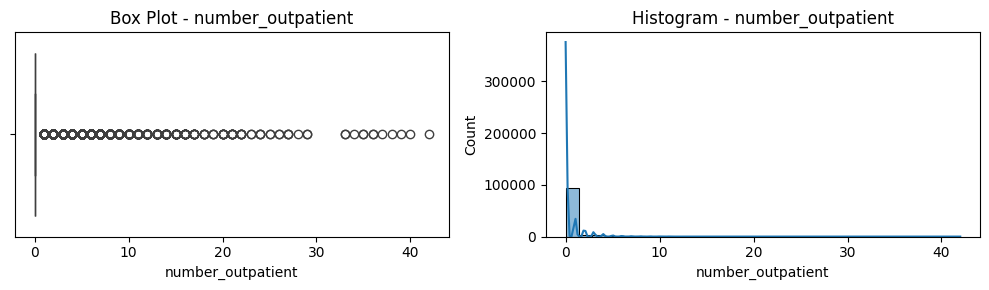

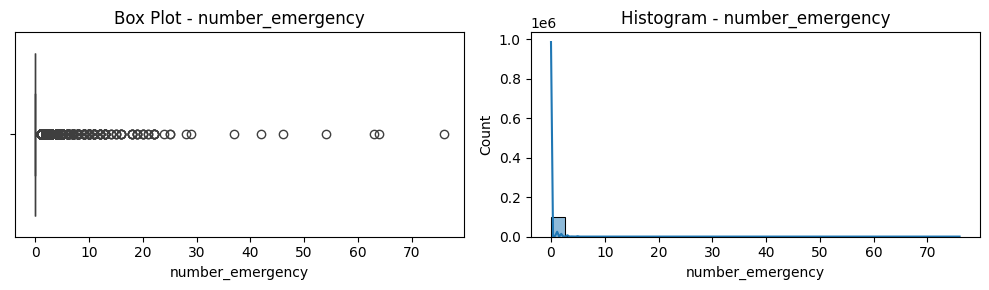

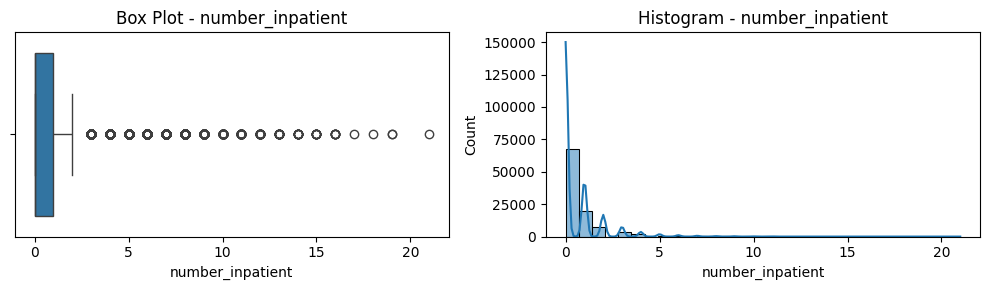

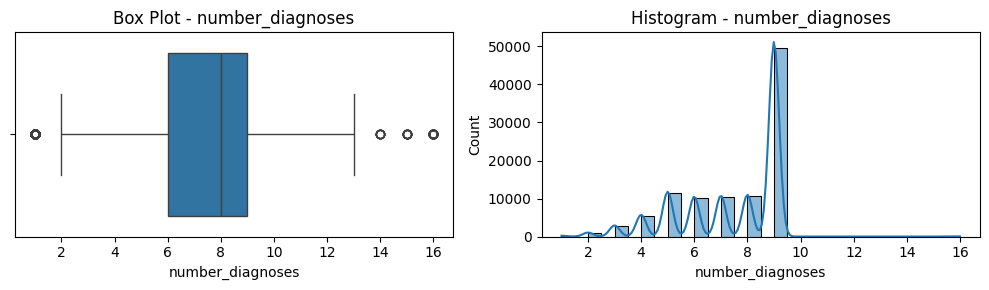

In [ ]:
# get the relevant numeric columns
numeric_cols = [
    'time_in_hospital',
    'num_lab_procedures',
    'num_procedures',
    'num_medications',
    'number_outpatient',
    'number_emergency',
    'number_inpatient',
    'number_diagnoses'
]

for col in numeric_cols:
    fig, axes = plt.subplots(1, 2, figsize=(10, 3))

    # Box plot
    sns.boxplot(x=DiabData_df[col], ax=axes[0])
    axes[0].set_title(f'Box Plot - {col}')

    # Histogram
    sns.histplot(DiabData_df[col], bins=30, kde=True, ax=axes[1])
    axes[1].set_title(f'Histogram - {col}')

    plt.tight_layout()
    plt.show()

The dataset exhibits significant variability across clinical and utilization variables, with evidence of skewness and outliers, particularly in prior healthcare usage and treatment intensity measures. These extreme values represent high-risk patient populations rather than data anomalies and were therefore retained. The target variable is relatively balanced, supporting classification modeling while allowing for analysis of imbalance effects. These characteristics informed preprocessing decisions, including feature scaling and retention of clinically meaningful variability for predictive modeling and bias analysis.

# Prepare Data for Modelling

In [ ]:
race_series = DiabData_df['race_group'].copy()
age_series = DiabData_df['age_group'].copy()
gender_series = DiabData_df['gender'].copy()

In [ ]:
race_series

,race_group
0,Caucasian
1,Caucasian
2,AfricanAmerican
3,Caucasian
4,Caucasian
...,...
101761,AfricanAmerican
101762,AfricanAmerican
101763,Caucasian
101764,Caucasian


In [ ]:
DiabData_df

,gender,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,max_glu_serum,A1Cresult,insulin,change,diabetesMed,age_group,readmitted_binary,race_group
0,Female,6,25,1,1,41,0,1,0,0,0,1,None,None,No,No,No,Upto60,0,Caucasian
1,Female,1,1,7,3,59,0,18,0,0,0,9,None,None,Up,Ch,Yes,Upto60,1,Caucasian
2,Female,1,1,7,2,11,5,13,2,0,1,6,None,None,No,No,Yes,Upto60,0,AfricanAmerican
3,Male,1,1,7,2,44,1,16,0,0,0,7,None,None,Up,Ch,Yes,Upto60,0,Caucasian
4,Male,1,1,7,1,51,0,8,0,0,0,5,None,None,Steady,Ch,Yes,Upto60,0,Caucasian
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,Male,1,3,7,3,51,0,16,0,0,0,9,None,>8,Down,Ch,Yes,Senior,1,AfricanAmerican
101762,Female,1,4,5,5,33,3,18,0,0,1,9,None,None,Steady,No,Yes,Upto60,0,AfricanAmerican
101763,Male,1,1,7,1,53,0,9,1,0,0,13,None,None,Down,Ch,Yes,Senior,0,Caucasian
101764,Female,2,3,7,10,45,2,21,0,0,1,9,None,None,Up,Ch,Yes,Upto60,0,Caucasian


Categorical variables were encoded using one-hot encoding, while numerical variables were standardized to ensure consistent scaling. Logistic regression models were then trained using these transformed features, allowing the model to learn linear relationships between predictors and the probability of readmission.

In [ ]:
# Define Features & Target
X = DiabData_df.drop(columns=['readmitted_binary'])
X_encoded = pd.get_dummies(X, drop_first=True)
y = DiabData_df['readmitted_binary']

In [ ]:
X_encoded.shape

(101766, 27)

In [ ]:
y.shape

(101766,)

In [ ]:
# Train-Test Split with straified split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [ ]:
# --------------------------------------------------
# Scale only the original numeric columns
# --------------------------------------------------

numeric_cols = [
    'time_in_hospital',
    'num_lab_procedures',
    'num_procedures',
    'num_medications',
    'number_outpatient',
    'number_emergency',
    'number_inpatient',
    'number_diagnoses'
]

# Keep only numeric columns that are actually present
numeric_cols = [col for col in numeric_cols if col in X_train.columns]

scaler = StandardScaler()

X_train = X_train.copy()
X_test = X_test.copy()

X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

print("Scaled columns:", numeric_cols)
print(X_train[numeric_cols].head())

Scaled columns: ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']
       time_in_hospital  num_lab_procedures  num_procedures  num_medications  \
25118           0.20287             1.16401        -0.19949         -0.37063   
63601          -0.13190            -0.00331         0.97173          0.86104   
19781          -0.46667            -1.01837        -0.19949          0.61471   
94149          -0.46667             0.75799        -0.78509          0.98421   
68161          -0.13190             0.96100        -0.19949         -0.49379   

       number_outpatient  number_emergency  number_inpatient  number_diagnoses  
25118           -0.29167          -0.21325          -0.50299          -0.21711  
63601            0.49898           0.86642           0.28910           0.81732  
19781            2.87092           0.86642           0.28910          -2.28598  
94149           -0

# Common Functions across RQ1 and RQ2

In [ ]:

def train_and_predict_models(X_train, X_test, y_train, y_test, source_df):
    """
    Train the 3 models once and return prediction results dataframes
    with subgroup columns reattached.
    """

    # Reattach subgroup columns from original dataframe
    demographics = pd.DataFrame({
        'gender': source_df.loc[X_test.index, 'gender'].values,
        'age_group': source_df.loc[X_test.index, 'age_group'].values,
        'race_group': source_df.loc[X_test.index, 'race_group'].values
    }, index=X_test.index)

    models = {
        'Logistic Regression': LogisticRegression(max_iter=2000, solver='lbfgs', random_state=42),
        'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
        'Gradient Boosting': GradientBoostingClassifier(random_state=42)
    }

    results_by_model = {}

    for model_name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        results = demographics.copy()
        results['actual'] = y_test.values
        results['predicted'] = y_pred
        results['correct'] = (results['actual'] == results['predicted']).astype(int)

        results_by_model[model_name] = results

    return results_by_model

# Research question #1 : Accuracy across groups

In [ ]:
def run_rq1_test(results_df, group_col):
    """
    Run RQ1 accuracy comparison for one demographic variable.
    Returns summary table, contingency table, and p-value.
    """

    # Accuracy summary
    summary = results_df.groupby(group_col)['correct'].agg(['sum', 'count'])
    summary['accuracy'] = summary['sum'] / summary['count']

    # Contingency table: group vs correct/incorrect
    contingency = pd.crosstab(results_df[group_col], results_df['correct'])

    # Chi-square test
    chi2, p_value, _, _ = chi2_contingency(contingency)

    return summary, contingency, p_value

In [ ]:
def run_rq1_all_models(results_by_model):
    """
    Run RQ1 for all 3 models across gender, age_group, and race_group.
    Returns:
    - nested results dictionary
    - summary dataframe of p-values
    """

    demographic_groups = ['gender', 'age_group', 'race_group']
    rq1_outputs = {}
    summary_rows = []

    for model_name, results_df in results_by_model.items():
        rq1_outputs[model_name] = {}

        for group_col in demographic_groups:
            summary, contingency, p_value = run_rq1_test(results_df, group_col)

            rq1_outputs[model_name][group_col] = {
                'summary': summary,
                'contingency': contingency,
                'p_value': p_value
            }

            summary_rows.append({
                'Model': model_name,
                'Demographic Group': group_col,
                'p-value': p_value
            })

    summary_df = pd.DataFrame(summary_rows)

    return rq1_outputs, summary_df

In [ ]:
# Train all 3 models once and get predictions
results_by_model = train_and_predict_models(
    X_train, X_test, y_train, y_test, DiabData_df
)

# Run RQ1 across all models and demographic groups
rq1_outputs, rq1_pvalue_summary = run_rq1_all_models(results_by_model)

# View p-value summary
print(rq1_pvalue_summary)

                 Model Demographic Group  p-value
0  Logistic Regression            gender  0.17020
1  Logistic Regression         age_group  0.00000
2  Logistic Regression        race_group  0.04386
3        Random Forest            gender  0.49539
4        Random Forest         age_group  0.00000
5        Random Forest        race_group  0.01716
6    Gradient Boosting            gender  0.76704
7    Gradient Boosting         age_group  0.00001
8    Gradient Boosting        race_group  0.01942


In [ ]:
rq1_pvalue_pivot = rq1_pvalue_summary.pivot(
    index='Model',
    columns='Demographic Group',
    values='p-value'
)

print(rq1_pvalue_pivot)

Demographic Group    age_group  gender  race_group
Model                                             
Gradient Boosting      0.00001 0.76704     0.01942
Logistic Regression    0.00000 0.17020     0.04386
Random Forest          0.00000 0.49539     0.01716


In [ ]:
def print_rq1_results(rq1_outputs, model_name, group_col):
    obj = rq1_outputs[model_name][group_col]

    print("=" * 60)
    print(f"Model: {model_name}")
    print(f"Demographic Group: {group_col}")
    print("=" * 60)

    print("\nSummary (Accuracy Table):")
    print(obj['summary'].to_string())

    print("\nContingency Table (Correct vs Incorrect):")
    print(obj['contingency'].to_string())

    print(f"\nChi-square p-value: {obj['p_value']:.6f}")
    print("=" * 60)

In [ ]:
print_rq1_results(rq1_outputs, 'Logistic Regression', 'gender')
print_rq1_results(rq1_outputs, 'Logistic Regression', 'race_group')
print_rq1_results(rq1_outputs, 'Logistic Regression', 'age_group')

Model: Logistic Regression
Demographic Group: gender

Summary (Accuracy Table):
         sum  count  accuracy
gender                       
Female  6709  10922   0.61426
Male    5883   9432   0.62373

Contingency Table (Correct vs Incorrect):
correct     0     1
gender             
Female   4213  6709
Male     3549  5883

Chi-square p-value: 0.170203
Model: Logistic Regression
Demographic Group: race_group

Summary (Accuracy Table):
                  sum  count  accuracy
race_group                            
AfricanAmerican  2353   3791   0.62068
Caucasian        9386  15251   0.61544
Other_Minority    853   1312   0.65015

Contingency Table (Correct vs Incorrect):
correct             0     1
race_group                 
AfricanAmerican  1438  2353
Caucasian        5865  9386
Other_Minority    459   853

Chi-square p-value: 0.043864
Model: Logistic Regression
Demographic Group: age_group

Summary (Accuracy Table):
            sum  count  accuracy
age_group                       
Senior

In [ ]:
print_rq1_results(rq1_outputs, 'Random Forest', 'gender')
print_rq1_results(rq1_outputs, 'Random Forest', 'race_group')
print_rq1_results(rq1_outputs, 'Random Forest', 'age_group')

Model: Random Forest
Demographic Group: gender

Summary (Accuracy Table):
         sum  count  accuracy
gender                       
Female  6871  10922   0.62910
Male    5889   9432   0.62436

Contingency Table (Correct vs Incorrect):
correct     0     1
gender             
Female   4051  6871
Male     3543  5889

Chi-square p-value: 0.495395
Model: Random Forest
Demographic Group: race_group

Summary (Accuracy Table):
                  sum  count  accuracy
race_group                            
AfricanAmerican  2381   3791   0.62807
Caucasian        9509  15251   0.62350
Other_Minority    870   1312   0.66311

Contingency Table (Correct vs Incorrect):
correct             0     1
race_group                 
AfricanAmerican  1410  2381
Caucasian        5742  9509
Other_Minority    442   870

Chi-square p-value: 0.017159
Model: Random Forest
Demographic Group: age_group

Summary (Accuracy Table):
            sum  count  accuracy
age_group                       
Senior     5938   9743  

In [ ]:
print_rq1_results(rq1_outputs, 'Gradient Boosting', 'gender')
print_rq1_results(rq1_outputs, 'Gradient Boosting', 'race_group')
print_rq1_results(rq1_outputs, 'Gradient Boosting', 'age_group')

Model: Gradient Boosting
Demographic Group: gender

Summary (Accuracy Table):
         sum  count  accuracy
gender                       
Female  6965  10922   0.63770
Male    5995   9432   0.63560

Contingency Table (Correct vs Incorrect):
correct     0     1
gender             
Female   3957  6965
Male     3437  5995

Chi-square p-value: 0.767040
Model: Gradient Boosting
Demographic Group: race_group

Summary (Accuracy Table):
                  sum  count  accuracy
race_group                            
AfricanAmerican  2434   3791   0.64205
Caucasian        9647  15251   0.63255
Other_Minority    879   1312   0.66997

Contingency Table (Correct vs Incorrect):
correct             0     1
race_group                 
AfricanAmerican  1357  2434
Caucasian        5604  9647
Other_Minority    433   879

Chi-square p-value: 0.019418
Model: Gradient Boosting
Demographic Group: age_group

Summary (Accuracy Table):
            sum  count  accuracy
age_group                       
Senior     6

# Research question #2 : False Negative Rate Disparities

In [ ]:
def run_rq2_test(results_df, group_col):
    """
    Run RQ2 false negative rate comparison for one demographic variable.

    Logic:
    - Restrict analysis to actual positive cases only
    - Among these, compare False Negative vs True Positive counts across groups
    - Compute FNR per group
    - Apply chi-square test on contingency table
    """

    # Keep only actual positives
    pos_df = results_df[results_df['actual'] == 1].copy()

    # Define FN and TP indicators
    pos_df['FN'] = (pos_df['predicted'] == 0).astype(int)
    pos_df['TP'] = (pos_df['predicted'] == 1).astype(int)

    # Summary table
    summary = pos_df.groupby(group_col)['FN'].agg(['sum', 'count'])
    summary['FNR'] = summary['sum'] / summary['count']

    # Contingency table: group vs predicted class among actual positives
    contingency = pd.crosstab(pos_df[group_col], pos_df['predicted'])

    # Ensure both columns exist for clean interpretation
    contingency = contingency.reindex(columns=[0, 1], fill_value=0)
    contingency.columns = ['False_Negative', 'True_Positive']

    # Chi-square test
    chi2, p_value, _, _ = chi2_contingency(contingency)

    return summary, contingency, p_value

In [ ]:
def run_rq2_all_models(results_by_model):
    """
    Run RQ2 for all models across gender, age_group, and race_group.

    Returns:
    - nested results dictionary
    - summary dataframe of p-values
    """

    demographic_groups = ['gender', 'age_group', 'race_group']
    rq2_outputs = {}
    summary_rows = []

    for model_name, results_df in results_by_model.items():
        rq2_outputs[model_name] = {}

        for group_col in demographic_groups:
            summary, contingency, p_value = run_rq2_test(results_df, group_col)

            rq2_outputs[model_name][group_col] = {
                'summary': summary,
                'contingency': contingency,
                'p_value': p_value
            }

            summary_rows.append({
                'Model': model_name,
                'Demographic Group': group_col,
                'p-value': p_value
            })

    summary_df = pd.DataFrame(summary_rows)

    return rq2_outputs, summary_df

In [ ]:
results_by_model = train_and_predict_models(
    X_train, X_test, y_train, y_test, DiabData_df
)

In [ ]:
# Run RQ2 across all models and demographic groups
rq2_outputs, rq2_pvalue_summary = run_rq2_all_models(results_by_model)
# View p-value summary
print(rq2_pvalue_summary)

                 Model Demographic Group  p-value
0  Logistic Regression            gender  0.00000
1  Logistic Regression         age_group  0.00000
2  Logistic Regression        race_group  0.00000
3        Random Forest            gender  0.00006
4        Random Forest         age_group  0.01506
5        Random Forest        race_group  0.00000
6    Gradient Boosting            gender  0.00019
7    Gradient Boosting         age_group  0.51122
8    Gradient Boosting        race_group  0.00000


In [ ]:
def print_rq2_results(rq2_outputs, model_name, group_col):
    obj = rq2_outputs[model_name][group_col]

    print("=" * 60)
    print(f"Model: {model_name}")
    print(f"Demographic Group: {group_col}")
    print("=" * 60)

    print("\nSummary (False Negative Rate Table):")
    print(obj['summary'].to_string())

    print("\nContingency Table (False Negatives vs True Positives):")
    print(obj['contingency'].to_string())

    print(f"\nChi-square p-value: {obj['p_value']:.6f}")
    print("=" * 60)

In [ ]:
print_rq2_results(rq2_outputs, 'Logistic Regression', 'gender')
print_rq2_results(rq2_outputs, 'Logistic Regression', 'age_group')
print_rq2_results(rq2_outputs, 'Logistic Regression', 'race_group')

Model: Logistic Regression
Demographic Group: gender

Summary (False Negative Rate Table):
         sum  count     FNR
gender                     
Female  2973   5219 0.56965
Male    2588   4162 0.62182

Contingency Table (False Negatives vs True Positives):
        False_Negative  True_Positive
gender                               
Female            2973           2246
Male              2588           1574

Chi-square p-value: 0.000000
Model: Logistic Regression
Demographic Group: age_group

Summary (False Negative Rate Table):
            sum  count     FNR
age_group                     
Senior     2622   4608 0.56901
Upto60     2939   4773 0.61576

Contingency Table (False Negatives vs True Positives):
           False_Negative  True_Positive
age_group                               
Senior               2622           1986
Upto60               2939           1834

Chi-square p-value: 0.000005
Model: Logistic Regression
Demographic Group: race_group

Summary (False Negative Rate Tabl

In [ ]:
print_rq2_results(rq2_outputs, 'Random Forest', 'gender')
print_rq2_results(rq2_outputs, 'Random Forest', 'age_group')
print_rq2_results(rq2_outputs, 'Random Forest', 'race_group')

Model: Random Forest
Demographic Group: gender

Summary (False Negative Rate Table):
         sum  count     FNR
gender                     
Female  2326   5219 0.44568
Male    2029   4162 0.48751

Contingency Table (False Negatives vs True Positives):
        False_Negative  True_Positive
gender                               
Female            2326           2893
Male              2029           2133

Chi-square p-value: 0.000059
Model: Random Forest
Demographic Group: age_group

Summary (False Negative Rate Table):
            sum  count     FNR
age_group                     
Senior     2080   4608 0.45139
Upto60     2275   4773 0.47664

Contingency Table (False Negatives vs True Positives):
           False_Negative  True_Positive
age_group                               
Senior               2080           2528
Upto60               2275           2498

Chi-square p-value: 0.015063
Model: Random Forest
Demographic Group: race_group

Summary (False Negative Rate Table):
              

In [ ]:
print_rq2_results(rq2_outputs, 'Gradient Boosting', 'gender')
print_rq2_results(rq2_outputs, 'Gradient Boosting', 'age_group')
print_rq2_results(rq2_outputs, 'Gradient Boosting', 'race_group')


Model: Gradient Boosting
Demographic Group: gender

Summary (False Negative Rate Table):
         sum  count     FNR
gender                     
Female  2573   5219 0.49301
Male    2214   4162 0.53196

Contingency Table (False Negatives vs True Positives):
        False_Negative  True_Positive
gender                               
Female            2573           2646
Male              2214           1948

Chi-square p-value: 0.000193
Model: Gradient Boosting
Demographic Group: age_group

Summary (False Negative Rate Table):
            sum  count     FNR
age_group                     
Senior     2335   4608 0.50673
Upto60     2452   4773 0.51372

Contingency Table (False Negatives vs True Positives):
           False_Negative  True_Positive
age_group                               
Senior               2335           2273
Upto60               2452           2321

Chi-square p-value: 0.511217
Model: Gradient Boosting
Demographic Group: race_group

Summary (False Negative Rate Table):
  

# Common functions across RQ3 and RQ4

In [ ]:

# --------------------------------------------------
# Core helpers
# --------------------------------------------------

def compute_fnr_gap(df, group_col, pred_col='predicted'):
    pos = df[df['actual'] == 1].copy()

    if pos.empty:
        return np.nan

    fnr = pos.groupby(group_col)[pred_col].apply(lambda x: (x == 0).mean())
    fnr = fnr.dropna()

    if len(fnr) < 2:
        return np.nan

    return fnr.max() - fnr.min()


def prepare_split(X_encoded, y, source_df, numeric_cols, random_state, test_size=0.2):
    X_train, X_test, y_train, y_test = train_test_split(
        X_encoded,
        y,
        test_size=test_size,
        stratify=y,
        random_state=random_state
    )

    scaler = StandardScaler()
    X_train = X_train.copy()
    X_test = X_test.copy()

    X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
    X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

    demographics = pd.DataFrame({
        'gender': source_df.loc[X_test.index, 'gender'].values,
        'age_group': source_df.loc[X_test.index, 'age_group'].values,
        'race_group': source_df.loc[X_test.index, 'race_group'].values
    }, index=X_test.index)

    return X_train, X_test, y_train, y_test, demographics


def build_results_df(y_test, y_pred, demographics, pred_col_name):
    results = demographics.copy()
    results['actual'] = y_test.values
    results[pred_col_name] = y_pred
    return results


def compute_all_fnr_gaps(results_df, pred_col):
    return {
        'gender': compute_fnr_gap(results_df, 'gender', pred_col),
        'age': compute_fnr_gap(results_df, 'age_group', pred_col),
        'race': compute_fnr_gap(results_df, 'race_group', pred_col)
    }


def rebalance_training_data(X_train, y_train, random_state):
    train_df = X_train.copy()
    train_df['target'] = y_train.values

    majority = train_df[train_df['target'] == 0]
    minority = train_df[train_df['target'] == 1]

    minority_upsampled = resample(
        minority,
        replace=True,
        n_samples=len(majority),
        random_state=random_state
    )

    balanced = pd.concat([majority, minority_upsampled]).sample(frac=1, random_state=random_state)

    Xb = balanced.drop(columns=['target'])
    yb = balanced['target']

    return Xb, yb


# --------------------------------------------------
# Model factory
# --------------------------------------------------

def make_model(model_name, mitigation='none', random_state=42):
    """
    mitigation options:
        'none'
        'class_weight'
    oversampling is handled at the data level, not here
    """

    if model_name == 'logistic':
        if mitigation == 'class_weight':
            return LogisticRegression(
                max_iter=2000,
                solver='lbfgs',
                class_weight='balanced',
                random_state=random_state
            )
        return LogisticRegression(
            max_iter=2000,
            solver='lbfgs',
            random_state=random_state
        )

    elif model_name == 'random_forest':
        if mitigation == 'class_weight':
            return RandomForestClassifier(
                n_estimators=200,
                class_weight='balanced',
                random_state=random_state,
                n_jobs=-1
            )
        return RandomForestClassifier(
            n_estimators=200,
            random_state=random_state,
            n_jobs=-1
        )

    elif model_name == 'gradient_boosting':
        # Standard GradientBoostingClassifier does not support class_weight directly
        if mitigation == 'class_weight':
            raise ValueError("Gradient Boosting does not directly support class_weight in this setup.")
        return GradientBoostingClassifier(random_state=random_state)

    else:
        raise ValueError("model_name must be: 'logistic', 'random_forest', or 'gradient_boosting'")


# --------------------------------------------------
# Statistical helper
# --------------------------------------------------

def run_paired_test(before, after, label):
    before = np.array(before, dtype=float)
    after = np.array(after, dtype=float)

    mask = ~np.isnan(before) & ~np.isnan(after)
    before = before[mask]
    after = after[mask]

    p = ttest_rel(before, after).pvalue

    print(f"{label} p-value: {p}")
    print(f"{label} mean BEFORE: {np.mean(before)}")
    print(f"{label} mean AFTER : {np.mean(after)}")
    print(f"{label} valid runs : {len(before)}")
    print("-" * 40)

    return {
        'label': label,
        'p_value': p,
        'mean_before': np.mean(before),
        'mean_after': np.mean(after),
        'valid_runs': len(before)
    }


# --------------------------------------------------
# Plot helpers
# --------------------------------------------------

def make_group_plot_df(before_dict, after_dict):
    dfs = []

    mapping = {
        'gender': 'Gender',
        'age': 'Age',
        'race': 'Race'
    }

    for key in ['gender', 'age', 'race']:
        df = pd.DataFrame({
            'Before': before_dict[key],
            'After': after_dict[key]
        }).melt(var_name='Condition', value_name='FNR Gap')
        df['Group'] = mapping[key]
        dfs.append(df)

    return pd.concat(dfs, ignore_index=True)


def plot_fnr_boxplots(before_dict, after_dict, title):
    df_all = make_group_plot_df(before_dict, after_dict)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

    for ax, grp in zip(axes, ['Gender', 'Age', 'Race']):
        subset = df_all[df_all['Group'] == grp]
        sns.boxplot(data=subset, x='Condition', y='FNR Gap', ax=ax)
        ax.set_title(grp)
        ax.set_xlabel('')
        if grp != 'Gender':
            ax.set_ylabel('')

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


def plot_fnr_means(before_dict, after_dict, title):
    labels = [
        'Gender Before', 'Gender After',
        'Age Before', 'Age After',
        'Race Before', 'Race After'
    ]

    means = [
        np.nanmean(before_dict['gender']), np.nanmean(after_dict['gender']),
        np.nanmean(before_dict['age']), np.nanmean(after_dict['age']),
        np.nanmean(before_dict['race']), np.nanmean(after_dict['race'])
    ]

    plt.figure(figsize=(10, 4))
    plt.bar(labels, means)
    plt.xticks(rotation=45)
    plt.ylabel('Mean FNR Gap')
    plt.title(title)
    plt.tight_layout()
    plt.show()


def plot_auc_boxplot(auc_before, auc_after, title):
    df_auc = pd.DataFrame({
        'Before': auc_before,
        'After': auc_after
    }).melt(var_name='Condition', value_name='AUC')

    plt.figure(figsize=(6, 4))
    sns.boxplot(x='Condition', y='AUC', data=df_auc)
    plt.title(title)
    plt.ylabel('AUC')
    plt.xlabel('')
    plt.tight_layout()
    plt.show()


# --------------------------------------------------
# Generic experiment runner
# --------------------------------------------------

def run_experiment(
    X_encoded,
    y,
    source_df,
    numeric_cols,
    model_name='logistic',
    compare_mode='rq3',
    mitigation_strategy='oversample',
    n_runs=35
):
    """
    compare_mode:
        'rq3' -> baseline vs mitigation_strategy (usually oversample)
        'rq4' -> baseline vs mitigation_strategy

    mitigation_strategy:
        'oversample'
        'class_weight'
    """

    gaps_before = {'gender': [], 'age': [], 'race': []}
    gaps_after = {'gender': [], 'age': [], 'race': []}

    auc_before = []
    auc_after = []

    for i in range(n_runs):
        X_train, X_test, y_train, y_test, demographics = prepare_split(
            X_encoded, y, source_df, numeric_cols, random_state=i
        )

        # -----------------------------
        # Baseline model
        # -----------------------------
        base_model = make_model(model_name, mitigation='none', random_state=i)
        base_model.fit(X_train, y_train)

        y_pred_base = base_model.predict(X_test)
        y_prob_base = base_model.predict_proba(X_test)[:, 1]

        results_base = build_results_df(y_test, y_pred_base, demographics, pred_col_name='predicted_base')
        base_gaps = compute_all_fnr_gaps(results_base, 'predicted_base')

        gaps_before['gender'].append(base_gaps['gender'])
        gaps_before['age'].append(base_gaps['age'])
        gaps_before['race'].append(base_gaps['race'])

        auc_before.append(roc_auc_score(y_test, y_prob_base))

        # -----------------------------
        # Comparison model
        # -----------------------------
        if mitigation_strategy == 'oversample':
            X_comp, y_comp = rebalance_training_data(X_train, y_train, random_state=i)
            comp_model = make_model(model_name, mitigation='none', random_state=i)

        elif mitigation_strategy == 'class_weight':
            if model_name == 'gradient_boosting':
                raise ValueError("Gradient Boosting does not support class_weight in this setup.")
            X_comp, y_comp = X_train, y_train
            comp_model = make_model(model_name, mitigation='class_weight', random_state=i)

        else:
            raise ValueError("mitigation_strategy must be 'oversample' or 'class_weight'")

        comp_model.fit(X_comp, y_comp)

        y_pred_comp = comp_model.predict(X_test)
        y_prob_comp = comp_model.predict_proba(X_test)[:, 1]

        results_comp = build_results_df(y_test, y_pred_comp, demographics, pred_col_name='predicted_comp')
        comp_gaps = compute_all_fnr_gaps(results_comp, 'predicted_comp')

        gaps_after['gender'].append(comp_gaps['gender'])
        gaps_after['age'].append(comp_gaps['age'])
        gaps_after['race'].append(comp_gaps['race'])

        auc_after.append(roc_auc_score(y_test, y_prob_comp))

    return {
        'model_name': model_name,
        'compare_mode': compare_mode,
        'mitigation_strategy': mitigation_strategy,
        'gaps_before': gaps_before,
        'gaps_after': gaps_after,
        'auc_before': auc_before,
        'auc_after': auc_after
    }

In [ ]:
def summarize_experiment(result_obj, label_prefix=None):
    """
    Creates a summary dataframe for one experiment result returned by run_experiment().
    """

    rows = []

    model_name = result_obj['model_name']
    mitigation = result_obj['mitigation_strategy']

    if label_prefix is None:
        label_prefix = f"{model_name}_{mitigation}"

    # demographic groups
    for group in ['gender', 'age', 'race']:
        before = np.array(result_obj['gaps_before'][group], dtype=float)
        after = np.array(result_obj['gaps_after'][group], dtype=float)

        mask = ~np.isnan(before) & ~np.isnan(after)
        before_clean = before[mask]
        after_clean = after[mask]

        p_val = ttest_rel(before_clean, after_clean).pvalue if len(before_clean) > 1 else np.nan

        rows.append({
            'Experiment': label_prefix,
            'Model': model_name,
            'Mitigation': mitigation,
            'Metric': 'FNR Gap',
            'Group': group.capitalize(),
            'Mean Before': np.mean(before_clean) if len(before_clean) > 0 else np.nan,
            'Mean After': np.mean(after_clean) if len(after_clean) > 0 else np.nan,
            'Delta (After-Before)': (
                np.mean(after_clean) - np.mean(before_clean)
                if len(before_clean) > 0 else np.nan
            ),
            'p-value': p_val,
            'Valid Runs': len(before_clean)
        })

    # AUC summary
    auc_before = np.array(result_obj['auc_before'], dtype=float)
    auc_after = np.array(result_obj['auc_after'], dtype=float)

    mask_auc = ~np.isnan(auc_before) & ~np.isnan(auc_after)
    auc_before = auc_before[mask_auc]
    auc_after = auc_after[mask_auc]

    p_auc = ttest_rel(auc_before, auc_after).pvalue if len(auc_before) > 1 else np.nan

    rows.append({
        'Experiment': label_prefix,
        'Model': model_name,
        'Mitigation': mitigation,
        'Metric': 'AUC',
        'Group': 'Overall',
        'Mean Before': np.mean(auc_before) if len(auc_before) > 0 else np.nan,
        'Mean After': np.mean(auc_after) if len(auc_after) > 0 else np.nan,
        'Delta (After-Before)': (
            np.mean(auc_after) - np.mean(auc_before)
            if len(auc_before) > 0 else np.nan
        ),
        'p-value': p_auc,
        'Valid Runs': len(auc_before)
    })

    return pd.DataFrame(rows)

# Research question #3 : Impact of Dataset Imbalance

In [ ]:
rq3_logistic = run_experiment(
    X_encoded=X_encoded,
    y=y,
    source_df=DiabData_df,
    numeric_cols=numeric_cols,
    model_name='logistic',
    compare_mode='rq3',
    mitigation_strategy='oversample',
    n_runs=35
)

In [ ]:
run_paired_test(rq3_logistic['gaps_before']['gender'], rq3_logistic['gaps_after']['gender'], "Gender RQ3 Logistic")
run_paired_test(rq3_logistic['gaps_before']['age'], rq3_logistic['gaps_after']['age'], "Age RQ3 Logistic")
run_paired_test(rq3_logistic['gaps_before']['race'], rq3_logistic['gaps_after']['race'], "Race RQ3 Logistic")

Gender RQ3 Logistic p-value: 1.2915806865941706e-06
Gender RQ3 Logistic mean BEFORE: 0.04979391396343032
Gender RQ3 Logistic mean AFTER : 0.060695692325342054
Gender RQ3 Logistic valid runs : 35
----------------------------------------
Age RQ3 Logistic p-value: 8.028995059786405e-18
Age RQ3 Logistic mean BEFORE: 0.04157777182097925
Age RQ3 Logistic mean AFTER : 0.06671668587465447
Age RQ3 Logistic valid runs : 35
----------------------------------------
Race RQ3 Logistic p-value: 1.9455731172143349e-22
Race RQ3 Logistic mean BEFORE: 0.19935874580946744
Race RQ3 Logistic mean AFTER : 0.2582238609537176
Race RQ3 Logistic valid runs : 35
----------------------------------------


{'label': 'Race RQ3 Logistic',
 'p_value': np.float64(1.9455731172143349e-22),
 'mean_before': np.float64(0.19935874580946744),
 'mean_after': np.float64(0.2582238609537176),
 'valid_runs': 35}

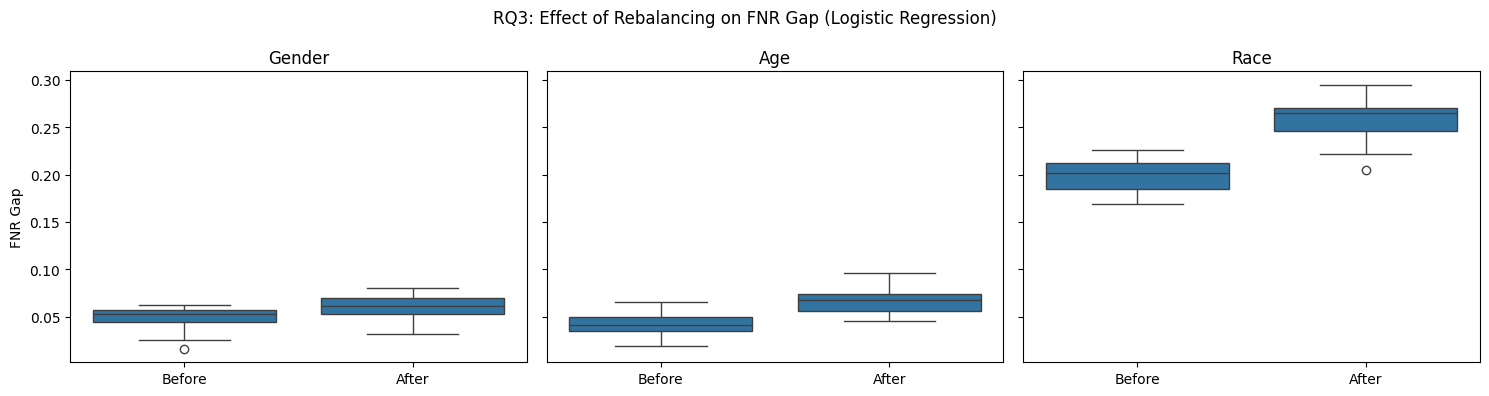

In [ ]:
plot_fnr_boxplots(
    rq3_logistic['gaps_before'],
    rq3_logistic['gaps_after'],
    title='RQ3: Effect of Rebalancing on FNR Gap (Logistic Regression)'
)

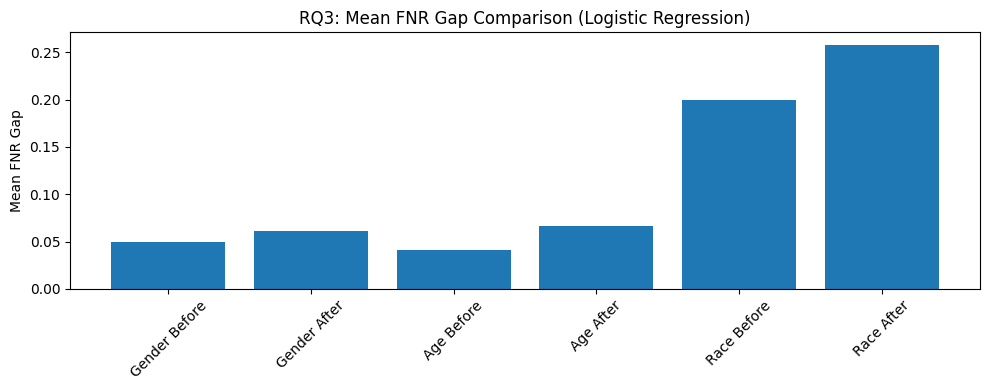

In [ ]:
plot_fnr_means(
    rq3_logistic['gaps_before'],
    rq3_logistic['gaps_after'],
    title='RQ3: Mean FNR Gap Comparison (Logistic Regression)'
)

In [ ]:
# Random Forest
rq3_rf = run_experiment(
    X_encoded=X_encoded,
    y=y,
    source_df=DiabData_df,
    numeric_cols=numeric_cols,
    model_name='random_forest',
    compare_mode='rq3',
    mitigation_strategy='oversample',
    n_runs=35
)

In [ ]:
run_paired_test(rq3_rf['gaps_before']['gender'], rq3_rf['gaps_after']['gender'], "Gender RQ3 RF")
run_paired_test(rq3_rf['gaps_before']['age'], rq3_rf['gaps_after']['age'], "Age RQ3 RF")
run_paired_test(rq3_rf['gaps_before']['race'], rq3_rf['gaps_after']['race'], "Race RQ3 RF")

Gender RQ3 RF p-value: 1.81048705892736e-06
Gender RQ3 RF mean BEFORE: 0.03974330180077423
Gender RQ3 RF mean AFTER : 0.031975155102625344
Gender RQ3 RF valid runs : 35
----------------------------------------
Age RQ3 RF p-value: 0.0013045555197514944
Age RQ3 RF mean BEFORE: 0.012687631447522166
Age RQ3 RF mean AFTER : 0.00675534847872808
Age RQ3 RF valid runs : 35
----------------------------------------
Race RQ3 RF p-value: 1.3320179514385995e-06
Race RQ3 RF mean BEFORE: 0.16436203187387036
Race RQ3 RF mean AFTER : 0.14766235357895233
Race RQ3 RF valid runs : 35
----------------------------------------


{'label': 'Race RQ3 RF',
 'p_value': np.float64(1.3320179514385995e-06),
 'mean_before': np.float64(0.16436203187387036),
 'mean_after': np.float64(0.14766235357895233),
 'valid_runs': 35}

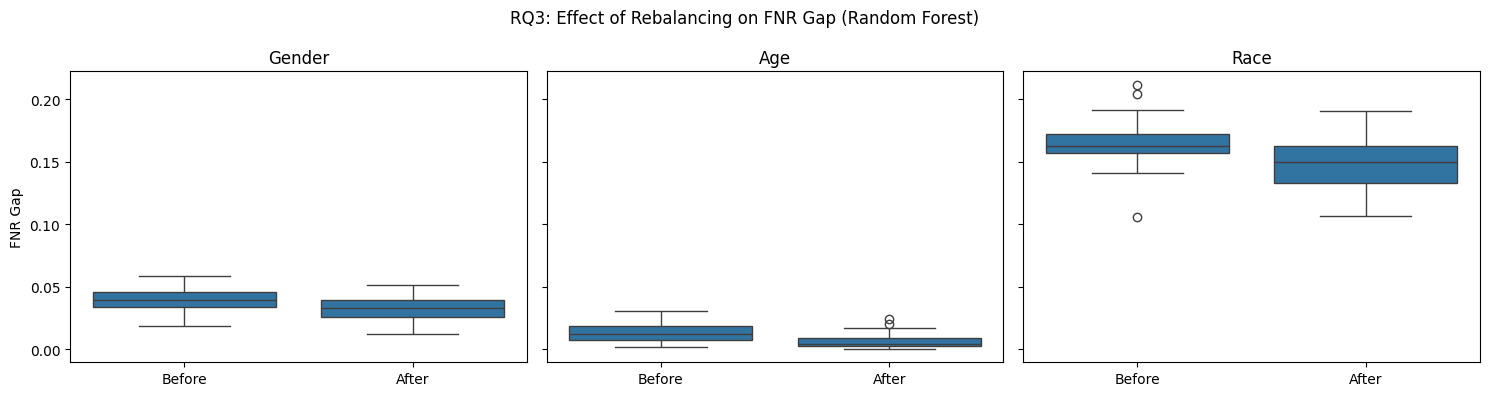

In [ ]:
plot_fnr_boxplots(
    rq3_rf['gaps_before'],
    rq3_rf['gaps_after'],
    title='RQ3: Effect of Rebalancing on FNR Gap (Random Forest)'
)

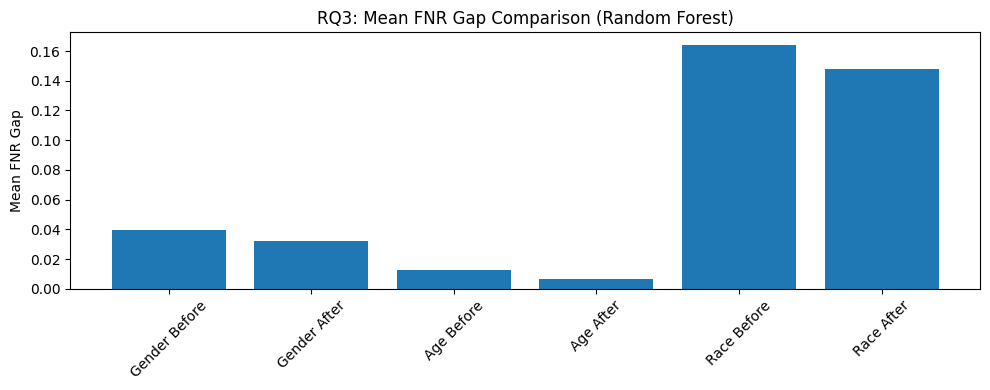

In [ ]:
plot_fnr_means(
    rq3_rf['gaps_before'],
    rq3_rf['gaps_after'],
    title='RQ3: Mean FNR Gap Comparison (Random Forest)'
)

In [ ]:
# Gradient Boosting
rq3_gb = run_experiment(
    X_encoded=X_encoded,
    y=y,
    source_df=DiabData_df,
    numeric_cols=numeric_cols,
    model_name='gradient_boosting',
    compare_mode='rq3',
    mitigation_strategy='oversample',
    n_runs=35
)

In [ ]:
run_paired_test(rq3_gb['gaps_before']['gender'], rq3_gb['gaps_after']['gender'], "Gender RQ3 GB")
run_paired_test(rq3_gb['gaps_before']['age'], rq3_gb['gaps_after']['age'], "Age RQ3 GB")
run_paired_test(rq3_gb['gaps_before']['race'], rq3_gb['gaps_after']['race'], "Race RQ3 GB")

Gender RQ3 GB p-value: 0.0029919644541609074
Gender RQ3 GB mean BEFORE: 0.031045187339613926
Gender RQ3 GB mean AFTER : 0.03593050038555646
Gender RQ3 GB valid runs : 35
----------------------------------------
Age RQ3 GB p-value: 3.4139619784832444e-14
Age RQ3 GB mean BEFORE: 0.008177784838448127
Age RQ3 GB mean AFTER : 0.03425426753118212
Age RQ3 GB valid runs : 35
----------------------------------------
Race RQ3 GB p-value: 1.7777524164811852e-13
Race RQ3 GB mean BEFORE: 0.15234777197601845
Race RQ3 GB mean AFTER : 0.18071040683751796
Race RQ3 GB valid runs : 35
----------------------------------------


{'label': 'Race RQ3 GB',
 'p_value': np.float64(1.7777524164811852e-13),
 'mean_before': np.float64(0.15234777197601845),
 'mean_after': np.float64(0.18071040683751796),
 'valid_runs': 35}

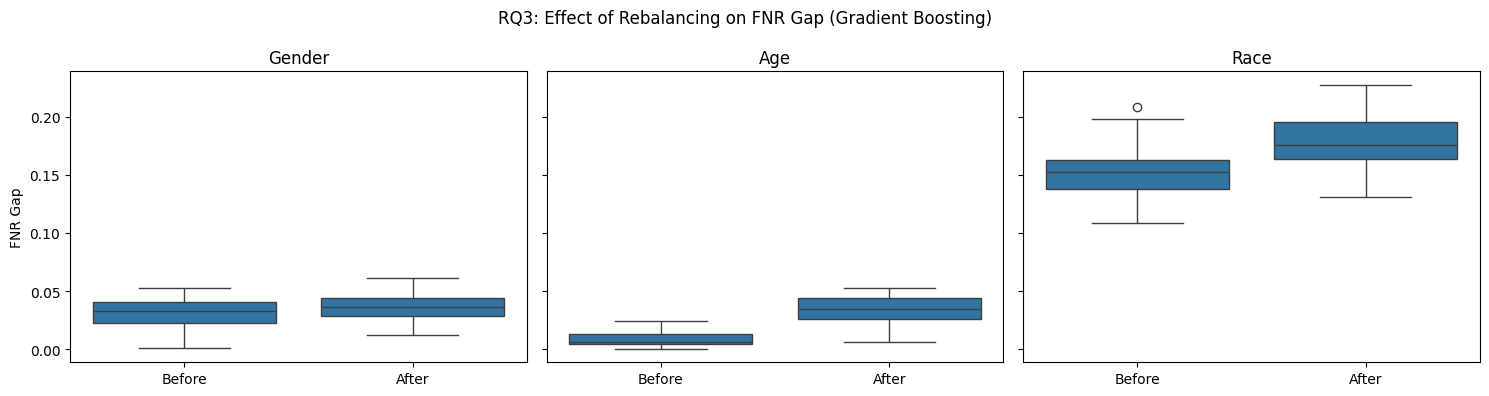

In [ ]:
plot_fnr_boxplots(
    rq3_gb['gaps_before'],
    rq3_gb['gaps_after'],
    title='RQ3: Effect of Rebalancing on FNR Gap (Gradient Boosting)'
)

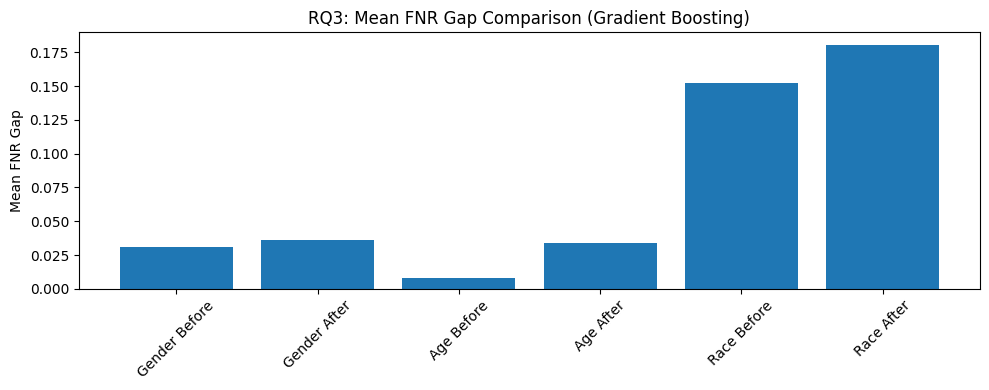

In [ ]:
plot_fnr_means(
    rq3_gb['gaps_before'],
    rq3_gb['gaps_after'],
    title='RQ3: Mean FNR Gap Comparison (Gradient Boosting)'
)

In [ ]:
summary_rq3 = pd.concat([
    summarize_experiment(rq3_logistic, "Logistic_RQ3"),
    summarize_experiment(rq3_rf, "RandomForest_RQ3"),
    summarize_experiment(rq3_gb, "GradientBoosting_RQ3")
], ignore_index=True)

summary_rq3

,Experiment,Model,Mitigation,Metric,Group,Mean Before,Mean After,Delta (After-Before),p-value,Valid Runs
0,Logistic_RQ3,logistic,oversample,FNR Gap,Gender,0.04979,0.06070,0.01090,0.00000,35
1,Logistic_RQ3,logistic,oversample,FNR Gap,Age,0.04158,0.06672,0.02514,0.00000,35
2,Logistic_RQ3,logistic,oversample,FNR Gap,Race,0.19936,0.25822,0.05887,0.00000,35
3,Logistic_RQ3,logistic,oversample,AUC,Overall,0.65578,0.65557,-0.00022,0.00005,35
4,RandomForest_RQ3,random_forest,oversample,FNR Gap,Gender,0.03974,0.03198,-0.00777,0.00000,35
5,RandomForest_RQ3,random_forest,oversample,FNR Gap,Age,0.01269,0.00676,-0.00593,0.00130,35
6,RandomForest_RQ3,random_forest,oversample,FNR Gap,Race,0.16436,0.14766,-0.01670,0.00000,35
7,RandomForest_RQ3,random_forest,oversample,AUC,Overall,0.67176,0.66817,-0.00358,0.00000,35
8,GradientBoosting_RQ3,gradient_boosting,oversample,FNR Gap,Gender,0.03105,0.03593,0.00489,0.00299,35
9,GradientBoosting_RQ3,gradient_boosting,oversample,FNR Gap,Age,0.00818,0.03425,0.02608,0.00000,35


# Research question #4 : Effectiveness of Bias Mitigation

In [ ]:
rq4_logistic_cw = run_experiment(
    X_encoded=X_encoded,
    y=y,
    source_df=DiabData_df,
    numeric_cols=numeric_cols,
    model_name='logistic',
    compare_mode='rq4',
    mitigation_strategy='class_weight',
    n_runs=35
)

In [ ]:
run_paired_test(rq4_logistic_cw['gaps_before']['gender'], rq4_logistic_cw['gaps_after']['gender'], "Gender RQ4 Logistic ClassWeight")
run_paired_test(rq4_logistic_cw['gaps_before']['age'], rq4_logistic_cw['gaps_after']['age'], "Age RQ4 Logistic ClassWeight")
run_paired_test(rq4_logistic_cw['gaps_before']['race'], rq4_logistic_cw['gaps_after']['race'], "Race RQ4 Logistic ClassWeight")
run_paired_test(rq4_logistic_cw['auc_before'], rq4_logistic_cw['auc_after'], "AUC RQ4 Logistic ClassWeight")

Gender RQ4 Logistic ClassWeight p-value: 1.4231754365964491e-10
Gender RQ4 Logistic ClassWeight mean BEFORE: 0.04979391396343032
Gender RQ4 Logistic ClassWeight mean AFTER : 0.059907840319360375
Gender RQ4 Logistic ClassWeight valid runs : 35
----------------------------------------
Age RQ4 Logistic ClassWeight p-value: 2.903953721414919e-23
Age RQ4 Logistic ClassWeight mean BEFORE: 0.04157777182097925
Age RQ4 Logistic ClassWeight mean AFTER : 0.06799903561647874
Age RQ4 Logistic ClassWeight valid runs : 35
----------------------------------------
Race RQ4 Logistic ClassWeight p-value: 3.210326237860853e-27
Race RQ4 Logistic ClassWeight mean BEFORE: 0.19935874580946744
Race RQ4 Logistic ClassWeight mean AFTER : 0.25747286765496635
Race RQ4 Logistic ClassWeight valid runs : 35
----------------------------------------
AUC RQ4 Logistic ClassWeight p-value: 2.702954332228691e-09
AUC RQ4 Logistic ClassWeight mean BEFORE: 0.6557845042245526
AUC RQ4 Logistic ClassWeight mean AFTER : 0.6558378

{'label': 'AUC RQ4 Logistic ClassWeight',
 'p_value': np.float64(2.702954332228691e-09),
 'mean_before': np.float64(0.6557845042245526),
 'mean_after': np.float64(0.6558378785264611),
 'valid_runs': 35}

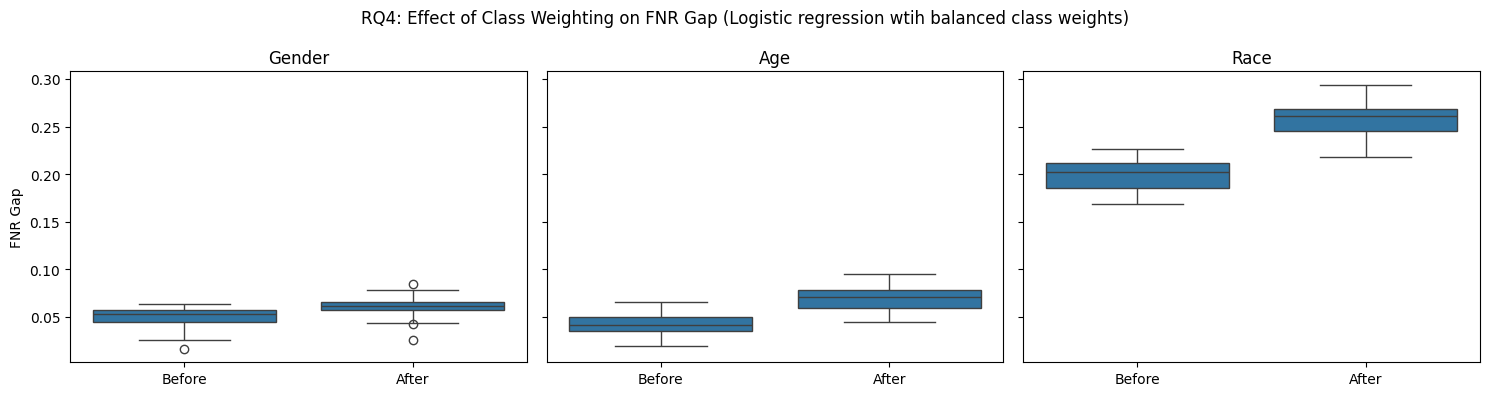

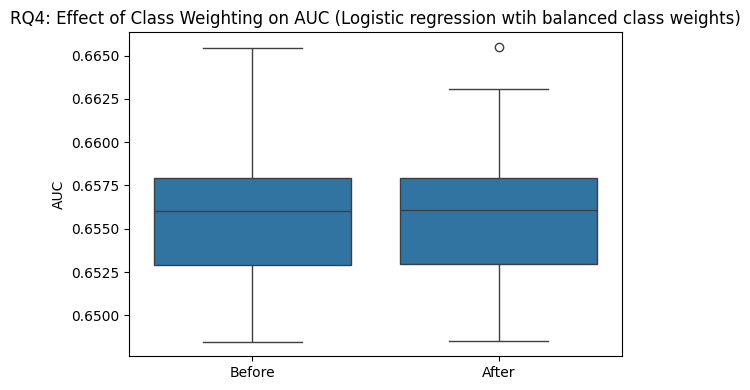

In [ ]:
plot_fnr_boxplots(
    rq4_logistic_cw['gaps_before'],
    rq4_logistic_cw['gaps_after'],
    title='RQ4: Effect of Class Weighting on FNR Gap (Logistic regression wtih balanced class weights)'
)

plot_auc_boxplot(
    rq4_logistic_cw['auc_before'],
    rq4_logistic_cw['auc_after'],
    title='RQ4: Effect of Class Weighting on AUC (Logistic regression wtih balanced class weights)'
)

In [ ]:
rq4_logistic_os = run_experiment(
    X_encoded=X_encoded,
    y=y,
    source_df=DiabData_df,
    numeric_cols=numeric_cols,
    model_name='logistic',
    compare_mode='rq4',
    mitigation_strategy='oversample',
    n_runs=35
)

In [ ]:
run_paired_test(rq4_logistic_os['gaps_before']['gender'], rq4_logistic_os['gaps_after']['gender'], "Gender RQ4 Logistic Oversample")
run_paired_test(rq4_logistic_os['gaps_before']['age'], rq4_logistic_os['gaps_after']['age'], "Age RQ4 Logistic Oversample")
run_paired_test(rq4_logistic_os['gaps_before']['race'], rq4_logistic_os['gaps_after']['race'], "Race RQ4 Logistic Oversample")
run_paired_test(rq4_logistic_os['auc_before'], rq4_logistic_os['auc_after'], "AUC RQ4 Logistic Oversample")

Gender RQ4 Logistic Oversample p-value: 1.2915806865941706e-06
Gender RQ4 Logistic Oversample mean BEFORE: 0.04979391396343032
Gender RQ4 Logistic Oversample mean AFTER : 0.060695692325342054
Gender RQ4 Logistic Oversample valid runs : 35
----------------------------------------
Age RQ4 Logistic Oversample p-value: 8.028995059786405e-18
Age RQ4 Logistic Oversample mean BEFORE: 0.04157777182097925
Age RQ4 Logistic Oversample mean AFTER : 0.06671668587465447
Age RQ4 Logistic Oversample valid runs : 35
----------------------------------------
Race RQ4 Logistic Oversample p-value: 1.9455731172143349e-22
Race RQ4 Logistic Oversample mean BEFORE: 0.19935874580946744
Race RQ4 Logistic Oversample mean AFTER : 0.2582238609537176
Race RQ4 Logistic Oversample valid runs : 35
----------------------------------------
AUC RQ4 Logistic Oversample p-value: 4.861068945600024e-05
AUC RQ4 Logistic Oversample mean BEFORE: 0.6557845042245526
AUC RQ4 Logistic Oversample mean AFTER : 0.6555668683144061
AUC R

{'label': 'AUC RQ4 Logistic Oversample',
 'p_value': np.float64(4.861068945600024e-05),
 'mean_before': np.float64(0.6557845042245526),
 'mean_after': np.float64(0.6555668683144061),
 'valid_runs': 35}

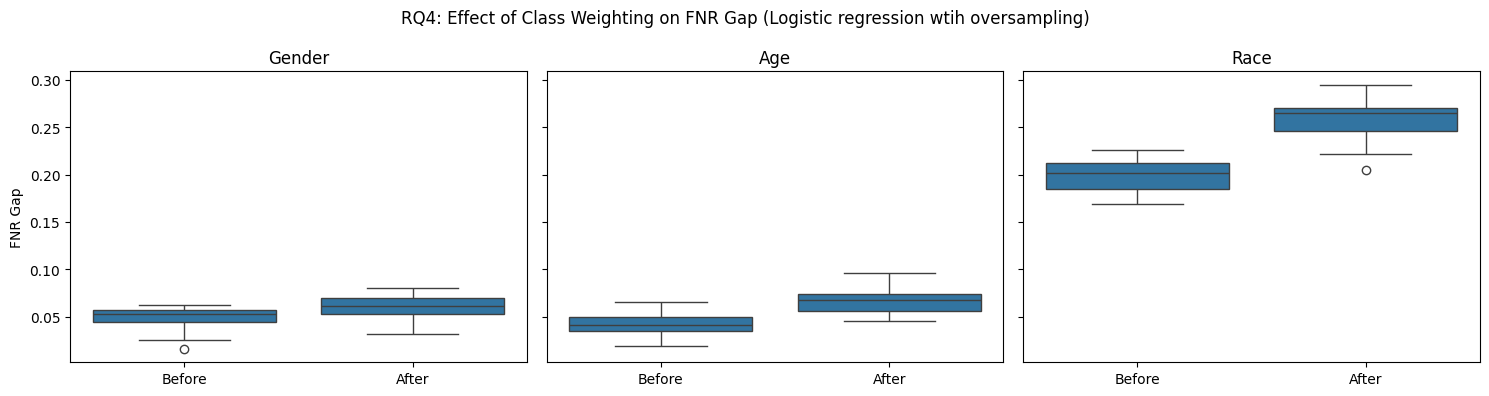

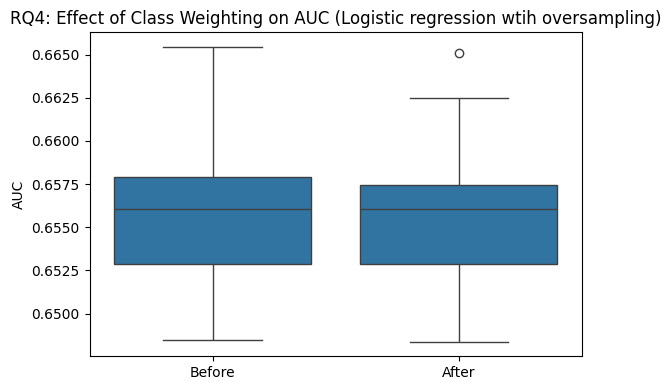

In [ ]:
plot_fnr_boxplots(
    rq4_logistic_os['gaps_before'],
    rq4_logistic_os['gaps_after'],
    title='RQ4: Effect of Class Weighting on FNR Gap (Logistic regression wtih oversampling)'
)

plot_auc_boxplot(
    rq4_logistic_os['auc_before'],
    rq4_logistic_os['auc_after'],
    title='RQ4: Effect of Class Weighting on AUC (Logistic regression wtih oversampling)'
)

In [ ]:
rq4_rf_cw = run_experiment(
    X_encoded=X_encoded,
    y=y,
    source_df=DiabData_df,
    numeric_cols=numeric_cols,
    model_name='random_forest',
    compare_mode='rq4',
    mitigation_strategy='class_weight',
    n_runs=35
)

In [ ]:
run_paired_test(rq4_rf_cw['gaps_before']['gender'], rq4_rf_cw['gaps_after']['gender'], "Gender RQ4 Logistic Oversample")
run_paired_test(rq4_rf_cw['gaps_before']['age'], rq4_rf_cw['gaps_after']['age'], "Age RQ4 Logistic Oversample")
run_paired_test(rq4_rf_cw['gaps_before']['race'], rq4_rf_cw['gaps_after']['race'], "Race RQ4 Logistic Oversample")
run_paired_test(rq4_rf_cw['auc_before'], rq4_rf_cw['auc_after'], "AUC RQ4 Logistic Oversample")

Gender RQ4 Logistic Oversample p-value: 0.20352029757643952
Gender RQ4 Logistic Oversample mean BEFORE: 0.03974330180077423
Gender RQ4 Logistic Oversample mean AFTER : 0.04094588940167994
Gender RQ4 Logistic Oversample valid runs : 35
----------------------------------------
Age RQ4 Logistic Oversample p-value: 0.7576395181288169
Age RQ4 Logistic Oversample mean BEFORE: 0.012687631447522166
Age RQ4 Logistic Oversample mean AFTER : 0.012409863568090346
Age RQ4 Logistic Oversample valid runs : 35
----------------------------------------
Race RQ4 Logistic Oversample p-value: 0.18550415721827362
Race RQ4 Logistic Oversample mean BEFORE: 0.16436203187387036
Race RQ4 Logistic Oversample mean AFTER : 0.1669622003980436
Race RQ4 Logistic Oversample valid runs : 35
----------------------------------------
AUC RQ4 Logistic Oversample p-value: 0.3431666016658672
AUC RQ4 Logistic Oversample mean BEFORE: 0.6717565366099456
AUC RQ4 Logistic Oversample mean AFTER : 0.6715843303915529
AUC RQ4 Logistic

{'label': 'AUC RQ4 Logistic Oversample',
 'p_value': np.float64(0.3431666016658672),
 'mean_before': np.float64(0.6717565366099456),
 'mean_after': np.float64(0.6715843303915529),
 'valid_runs': 35}

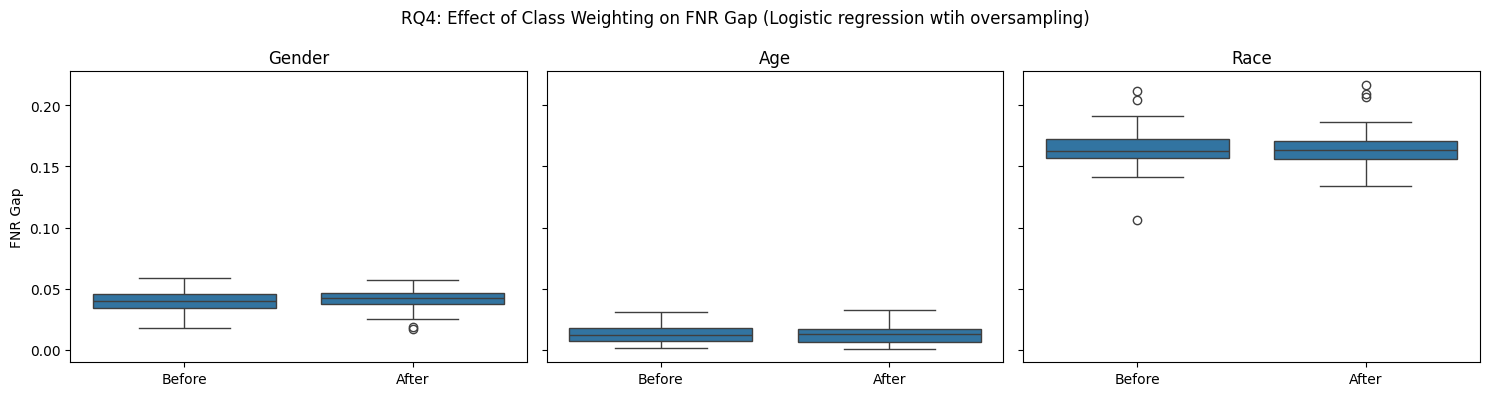

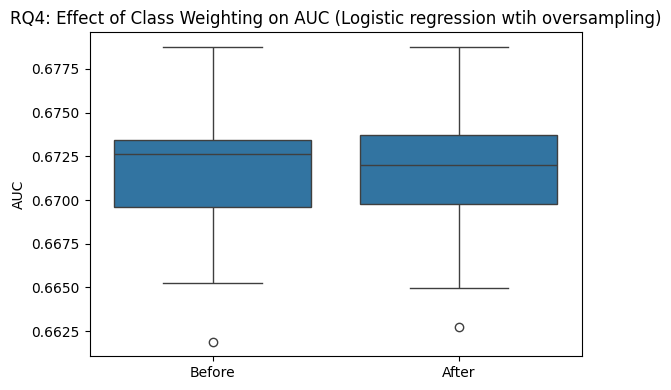

In [ ]:
plot_fnr_boxplots(
    rq4_rf_cw['gaps_before'],
    rq4_rf_cw['gaps_after'],
    title='RQ4: Effect of Class Weighting on FNR Gap (Logistic regression wtih oversampling)'
)

plot_auc_boxplot(
    rq4_rf_cw['auc_before'],
    rq4_rf_cw['auc_after'],
    title='RQ4: Effect of Class Weighting on AUC (Logistic regression wtih oversampling)'
)

In [ ]:
rq4_rf_os = run_experiment(
    X_encoded=X_encoded,
    y=y,
    source_df=DiabData_df,
    numeric_cols=numeric_cols,
    model_name='random_forest',
    compare_mode='rq4',
    mitigation_strategy='oversample',
    n_runs=35
)

In [ ]:
run_paired_test(rq4_rf_os['gaps_before']['gender'], rq4_rf_os['gaps_after']['gender'], "Gender RQ4 Logistic Oversample")
run_paired_test(rq4_rf_os['gaps_before']['age'], rq4_rf_os['gaps_after']['age'], "Age RQ4 Logistic Oversample")
run_paired_test(rq4_rf_os['gaps_before']['race'], rq4_rf_os['gaps_after']['race'], "Race RQ4 Logistic Oversample")
run_paired_test(rq4_rf_os['auc_before'], rq4_rf_os['auc_after'], "AUC RQ4 Logistic Oversample")

Gender RQ4 Logistic Oversample p-value: 1.81048705892736e-06
Gender RQ4 Logistic Oversample mean BEFORE: 0.03974330180077423
Gender RQ4 Logistic Oversample mean AFTER : 0.031975155102625344
Gender RQ4 Logistic Oversample valid runs : 35
----------------------------------------
Age RQ4 Logistic Oversample p-value: 0.0013045555197514944
Age RQ4 Logistic Oversample mean BEFORE: 0.012687631447522166
Age RQ4 Logistic Oversample mean AFTER : 0.00675534847872808
Age RQ4 Logistic Oversample valid runs : 35
----------------------------------------


NameError: name 'rq4_rf_oss' is not defined

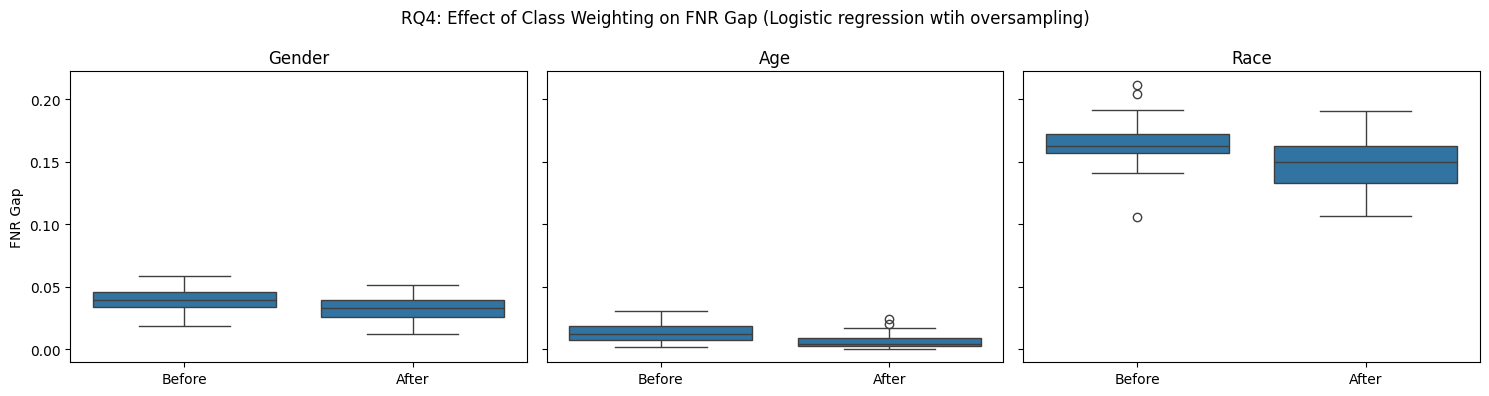

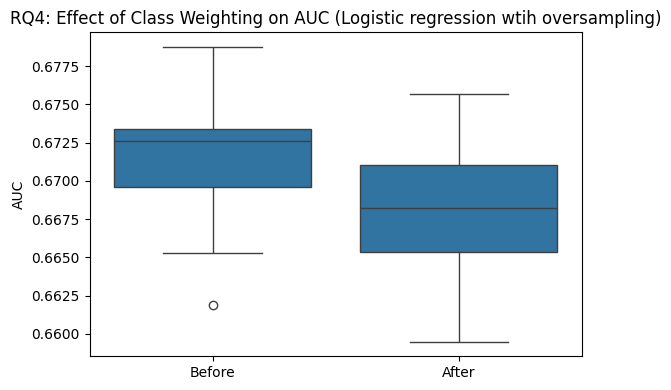

In [ ]:
plot_fnr_boxplots(
    rq4_rf_os['gaps_before'],
    rq4_rf_os['gaps_after'],
    title='RQ4: Effect of Class Weighting on FNR Gap (Logistic regression wtih oversampling)'
)

plot_auc_boxplot(
    rq4_rf_os['auc_before'],
    rq4_rf_os['auc_after'],
    title='RQ4: Effect of Class Weighting on AUC (Logistic regression wtih oversampling)'
)

In [ ]:
rq4_gb_os = run_experiment(
    X_encoded=X_encoded,
    y=y,
    source_df=DiabData_df,
    numeric_cols=numeric_cols,
    model_name='gradient_boosting',
    compare_mode='rq4',
    mitigation_strategy='oversample',
    n_runs=35
)

In [ ]:
run_paired_test(rq4_gb_os['gaps_before']['gender'], rq4_gb_os['gaps_after']['gender'], "Gender RQ4 Logistic Oversample")
run_paired_test(rq4_gb_os['gaps_before']['age'], rq4_gb_os['gaps_after']['age'], "Age RQ4 Logistic Oversample")
run_paired_test(rq4_gb_os['gaps_before']['race'], rq4_gb_os['gaps_after']['race'], "Race RQ4 Logistic Oversample")
run_paired_test(rq4_gb_os['auc_before'], rq4_gb_os['auc_after'], "AUC RQ4 Logistic Oversample")

Gender RQ4 Logistic Oversample p-value: 0.0029919644541609074
Gender RQ4 Logistic Oversample mean BEFORE: 0.031045187339613926
Gender RQ4 Logistic Oversample mean AFTER : 0.03593050038555646
Gender RQ4 Logistic Oversample valid runs : 35
----------------------------------------
Age RQ4 Logistic Oversample p-value: 3.4139619784832444e-14
Age RQ4 Logistic Oversample mean BEFORE: 0.008177784838448127
Age RQ4 Logistic Oversample mean AFTER : 0.03425426753118212
Age RQ4 Logistic Oversample valid runs : 35
----------------------------------------
Race RQ4 Logistic Oversample p-value: 1.7777524164811852e-13
Race RQ4 Logistic Oversample mean BEFORE: 0.15234777197601845
Race RQ4 Logistic Oversample mean AFTER : 0.18071040683751796
Race RQ4 Logistic Oversample valid runs : 35
----------------------------------------
AUC RQ4 Logistic Oversample p-value: 1.2730725293276407e-07
AUC RQ4 Logistic Oversample mean BEFORE: 0.6891633423297167
AUC RQ4 Logistic Oversample mean AFTER : 0.6884462680567118
AU

{'label': 'AUC RQ4 Logistic Oversample',
 'p_value': np.float64(1.2730725293276407e-07),
 'mean_before': np.float64(0.6891633423297167),
 'mean_after': np.float64(0.6884462680567118),
 'valid_runs': 35}

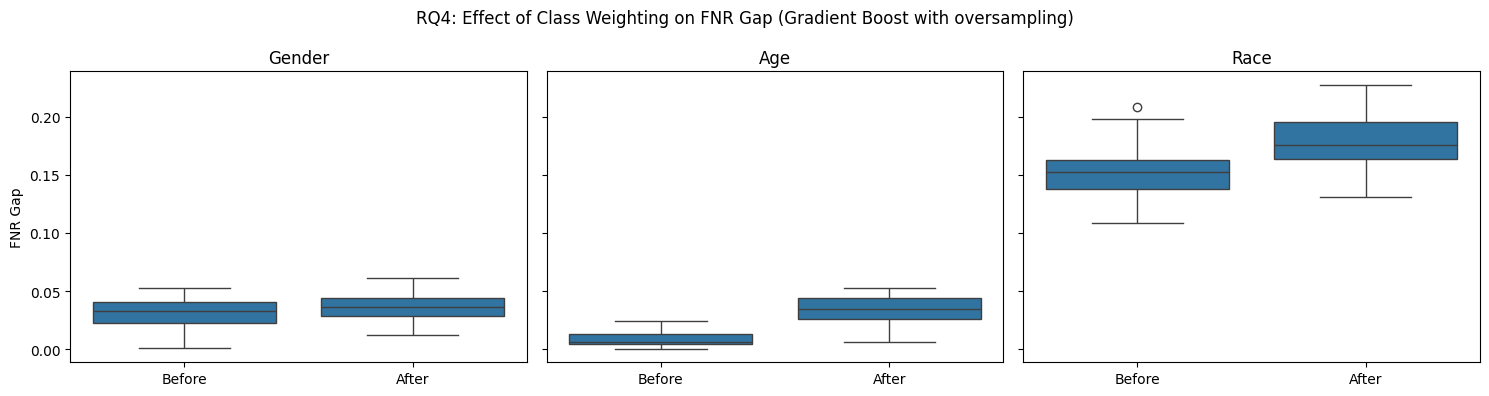

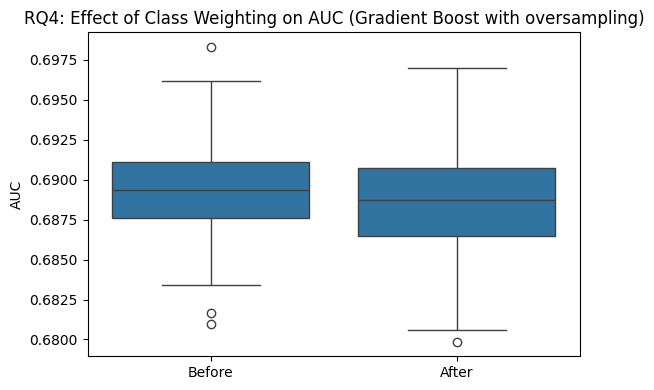

In [ ]:
plot_fnr_boxplots(
    rq4_gb_os['gaps_before'],
    rq4_gb_os['gaps_after'],
    title='RQ4: Effect of Class Weighting on FNR Gap (Gradient Boost with oversampling)'
)

plot_auc_boxplot(
    rq4_gb_os['auc_before'],
    rq4_gb_os['auc_after'],
    title='RQ4: Effect of Class Weighting on AUC (Gradient Boost with oversampling)'
)

In [ ]:
summary_rq4 = pd.concat([
    summarize_experiment(rq4_logistic_cw, "Logistic_RQ4 with class weights"),
    summarize_experiment(rq4_logistic_os, "Logistic_RQ4 with oversampling"),
    summarize_experiment(rq4_rf_cw, "RandomForest_RQ4 with class weights"),
    summarize_experiment(rq4_rf_os, "RandomForest_RQ4 with oversampling"),
    summarize_experiment(rq4_gb_os, "GradientBoost_RQ4 with oversampling")
], ignore_index=True)

summary_rq4

,Experiment,Model,Mitigation,Metric,Group,Mean Before,Mean After,Delta (After-Before),p-value,Valid Runs
0,Logistic_RQ4 with class weights,logistic,class_weight,FNR Gap,Gender,0.04979,0.05991,0.01011,0.00000,35
1,Logistic_RQ4 with class weights,logistic,class_weight,FNR Gap,Age,0.04158,0.06800,0.02642,0.00000,35
2,Logistic_RQ4 with class weights,logistic,class_weight,FNR Gap,Race,0.19936,0.25747,0.05811,0.00000,35
3,Logistic_RQ4 with class weights,logistic,class_weight,AUC,Overall,0.65578,0.65584,0.00005,0.00000,35
4,Logistic_RQ4 with oversampling,logistic,oversample,FNR Gap,Gender,0.04979,0.06070,0.01090,0.00000,35
5,Logistic_RQ4 with oversampling,logistic,oversample,FNR Gap,Age,0.04158,0.06672,0.02514,0.00000,35
6,Logistic_RQ4 with oversampling,logistic,oversample,FNR Gap,Race,0.19936,0.25822,0.05887,0.00000,35
7,Logistic_RQ4 with oversampling,logistic,oversample,AUC,Overall,0.65578,0.65557,-0.00022,0.00005,35
8,RandomForest_RQ4 with class weights,random_forest,class_weight,FNR Gap,Gender,0.03974,0.04095,0.00120,0.20352,35
9,RandomForest_RQ4 with class weights,random_forest,class_weight,FNR Gap,Age,0.01269,0.01241,-0.00028,0.75764,35
